In [1]:
import pandas as pd
import numpy as np
import jax.numpy as jnp
import jax
from memo import memo
from functools import partial
import json

import optax

import matplotlib.pyplot as plt
from matplotlib.legend_handler import HandlerBase
from matplotlib.colors import to_rgba

from matplotlib.patches import Rectangle
import seaborn as sns
# Make times new roman the default font
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 12
from enum import IntEnum
import itertools
import os

from mpl_toolkits.axes_grid1 import make_axes_locatable
from ipywidgets import interact, fixed
import ipywidgets as widgets

import statsmodels.formula.api as smf  
import statsmodels.api as sm
from patsy.contrasts import Treatment

# Remove pandas warnings
pd.options.mode.chained_assignment = None  # default='warn'

# Generic utility functions

In [2]:


K_values = 17
alphas_idx = jnp.arange(K_values)
alphas = jnp.linspace(-1, 1, alphas_idx.size)
alphas = jnp.linspace(0.01, .99, alphas_idx.size)

betas_idx = jnp.arange(K_values)
betas = jnp.linspace(-1, 1, betas_idx.size)

deltas_idx = jnp.arange(K_values)
deltas = jnp.linspace(0, 1, deltas_idx.size)


#param_values = jnp.array([betas, deltas, betas]).T

class F(IntEnum): Apple = 0; Orange = 1
class Pref(IntEnum): Apple = -1; Neither=0; Orange = 1
class Pref(IntEnum): Apple = 0; Orange = 1
class Appetite(IntEnum): One = 1; Two = 2
class Care(IntEnum): Indifferent = 0; Help = 1
class Care_wHarm(IntEnum): Harm = -1; Indifferent = 0; Help = 1
class C_watches(IntEnum): Present=1; Absent=0
class A_k_B(IntEnum): Yes=1; No=0
class C_k_B(IntEnum): Yes=1; No=0
class C_k_care(IntEnum): Yes=1; No=0

def parse_code(code, pref_names=True):
    parts = code.split('-')
    if parts[0] == 'complementary':
        if pref_names:
            pref_A = Pref.Orange.name
            pref_B = Pref.Apple.name
        else:
            pref_A = Pref.Orange.value
            pref_B = Pref.Apple.value
    elif parts[0] == 'competitive':
        if pref_names:
            pref_A = Pref.Apple.name
            pref_B = Pref.Apple.name
        else:
            pref_A = Pref.Apple.value
            pref_B = Pref.Apple.value

    # parts[1].split(':')[1] is either 'Yes' or 'No'
    # Find the element of C_knows_B which is equal to the string in parts[1].split(':')[1]
    C_knows_B = C_k_B[parts[1].split(':')[1]]

    if pref_names == True:
        choice1 = F[parts[-1].split(';')[0]].name
        choice2 = F[parts[-1].split(';')[1]].name
    else:
        choice1 = F[parts[-1].split(';')[0]]
        choice2 = F[parts[-1].split(';')[1]]
    n_apples, n_oranges = map(int, parts[-2].split('(')[1].split(')')[0].split(';'))
    
    
    return pref_A, pref_B, choice1, choice2, n_apples, n_oranges, C_knows_B

def story_data_to_id(pref_case, C_knows_B, C_knows_care, n_apples, n_oranges, f_choices):
    fruit_choice_label = f"{F(f_choices[0]).name};{F(f_choices[1]).name}"
    return f"{pref_case}-C_knows_B:{C_knows_B.name}-C_knows_care:{C_knows_care.name}-n_fruits({n_apples};{n_oranges})-{fruit_choice_label}"

def id_to_story_data(code, out_type='jnp'):
    parts = code.split('-')
    pref_case = parts[0]
    C_knows_B = C_k_B[parts[1].split(':')[1]]
    C_knows_care = C_k_care[parts[2].split(':')[1]]
    n_apples, n_oranges = map(int, parts[-2].split('(')[1].split(')')[0].split(';'))
    f_choices = tuple(F[choice] for choice in parts[-1].split(';'))

    if out_type == 'jnp':
        pref_case = (Pref.Orange.value, Pref.Apple.value) if pref_case == 'complementary' else (Pref.Apple.value, Pref.Apple.value)
        C_knows_B = C_knows_B.value
        C_knows_care = C_knows_care.value
        f_choices = (f_choices[0].value, f_choices[1].value)
        return jnp.array([
            pref_case[0], 
            0, # A_k_B.Yes.value, --- IGNORE ---
            pref_case[1], 
            n_apples, n_oranges,
            A_k_B.Yes,
            C_k_B.Yes,
            C_knows_B, 
            C_knows_care,
            f_choices[0], f_choices[1]
        ])
    elif out_type == 'dict':
        return dict(
            preferences=pref_case, 
            C_knows_B=C_knows_B, 
            C_knows_care=C_knows_care, 
            n_apples=n_apples, 
            n_oranges=n_oranges, 
            choice_1=f_choices[0],
            choice_2=f_choices[1]
        )
    else:
        return pref_case, C_knows_B, C_knows_care, n_apples, n_oranges, f_choices
    
def get_im_codes(pref_R, pref_G, choice1, choice2, n_apples, n_oranges, P_knows_G):

    if P_knows_G == C_k_B.Yes:
        present = "present"
    else:
        present = "absent"

    sim_code = f"sim_R-{pref_R.name[0]}_G-{pref_G.name[0]}_P-{present}"
    # Num fruits
    n_fruits = "A"* n_apples + "O"*n_oranges
    seq_code_1 = f"seq_{n_fruits}_R-{choice1.name[0]}_P-absent"
    seq_code_2 = f"seq_{n_fruits}_R-{choice2.name[0]}_P-present"

    return sim_code, seq_code_1, seq_code_2

# Import and process data

In [6]:
data_folder = '../data/exp1/'

raw_data_trials = pd.DataFrame()
raw_data_demos = pd.DataFrame()

# Load the all CSV files in the data folder in the raw_data DataFrame
pids = []
pid_idx = 0
for file in os.listdir(data_folder):
    #print(f"Processing file: {file}")
    if file.endswith('.csv'):
        if 'trials' in file:
            df = pd.read_csv(os.path.join(data_folder, file))
            raw_data_trials = pd.concat([raw_data_trials, df], ignore_index=True)
        if 'participant' in file:
            df = pd.read_csv(os.path.join(data_folder, file))
            raw_data_demos = pd.concat([raw_data_demos, df], ignore_index=True)

        # Get the pid
        pid = file.split('_')[0]
        if pid not in pids:
            pids.append(pid)

        # Replace prolific pid with a numeric id
        df['prolific_id'] = df['id']
        # Save the updated DataFrame back to the CSV file
        df.to_csv(os.path.join('../data/exp1_anon', f'{df['prolific_id'][0]}_{file.split("_")[1]}'), index=False)
        


In [ ]:
data_folder = '../data/exp1/'

raw_data_trials = pd.DataFrame()
raw_data_demos = pd.DataFrame()

# Load the all CSV files in the data folder in the raw_data DataFrame
for file in os.listdir(data_folder):
    #print(f"Processing file: {file}")
    if file.endswith('.csv'):
        if 'trials' in file:
            df = pd.read_csv(os.path.join(data_folder, file))
            raw_data_trials = pd.concat([raw_data_trials, df], ignore_index=True)
        if 'participant' in file:
            df = pd.read_csv(os.path.join(data_folder, file))
            raw_data_demos = pd.concat([raw_data_demos, df], ignore_index=True)

# Demographics
df_demos = raw_data_demos.copy()

# Split the 'story_id' column into multiple columns using the parse_code function
raw_data_trials[['pref_A', 'pref_B', 'choice1', 'choice2', 'n_apples', 'n_oranges', 'C_knows_B']] = raw_data_trials['story_id'].apply(parse_code, pref_names=True).apply(pd.Series)
raw_data_trials['preferences'] = raw_data_trials['story_id'].apply(lambda x: x.split('-')[0])

df_trials = raw_data_trials.copy()
df_trials['n_fruits'] = df_trials['n_apples'] + df_trials['n_oranges']

df_trials['vignette_order'] = df_trials['vignette_2'].map(lambda x: 'present' if 'present' in x else 'absent')
df_trials['social_goal'] = (df_trials['social_goal'].astype(float) - 50) / 50
df_trials['presentational_goal'] = df_trials['presentational_goal'].astype(float) / 100
df_trials['social_goal_purple'] = (df_trials['social_goal_purple'].astype(float) - 50) / 50

df_trials = df_trials[df_trials['n_fruits'] < 4].reset_index(drop=True)

goals_labels = ['social_goal', 'presentational_goal', 'social_goal_purple']

df_stories = df_trials.groupby(['story_id', 'n_fruits', 'preferences', 'choice1', 'choice2'])[goals_labels].mean().reset_index()

df_stories[[goal + '_std' for goal in goals_labels]] = df_trials.groupby(['story_id', 'n_fruits', 'preferences', 'choice1', 'choice2'])[goals_labels].std().reset_index()[goals_labels]

stories = df_stories['story_id'].sort_values().unique()

# Create a vectorized version of the data which should be N x n_stories x 3
data_as_jnp = jnp.zeros((df_trials['prolific_id'].unique().size, stories.size, 3))


# Make long format data for model fitting
dfl_trials = df_trials.melt(
    id_vars=['prolific_id', 'story_id', 'n_apples', 'n_oranges', 'preferences', 'choice1', 'choice2'], 
    value_vars=['social_goal', 'presentational_goal', 'social_goal_purple'],
    var_name='param_label',
    value_name='param_value'
)

### PREPARE DATA FOR MODEL FITTING
# Get unique prolific IDs and story IDs
prolific_ids = df_trials.sort_values(['prolific_id', 'story_id'])['prolific_id'].unique()
stories_all = df_trials.sort_values(['prolific_id', 'story_id'])['story_id'].unique()

grouped_data = (df_trials.sort_values(['prolific_id', 'story_id'])
                .groupby(['prolific_id', 'story_id'])[['social_goal', 'presentational_goal', 'social_goal_purple']]
                .mean())

# Convert to 3D array
data_as_jnp = grouped_data.values.reshape(
    len(grouped_data.index.get_level_values('prolific_id').unique()),  # n_prolific_ids
    len(grouped_data.index.get_level_values('story_id').unique()),     # n_story_ids  
    3  # 3 parameters
)
# Convert to JAX array
data_as_jnp = jax.device_put(data_as_jnp)
data_obs = data_as_jnp

# Create anther version with K_values dimension where the dimension is a one-hot encoding of the values
data_as_idx = jnp.argmin(jnp.abs(data_as_jnp[:, :, :, None] - jnp.array([betas, deltas, betas])[None, None, None :]), axis=-1)
data_obs_idx = data_as_idx

# Create one-hot encoding
data_as_onehot = jax.nn.one_hot(data_as_idx, K_values)


def get_hist(data_obs, vals):
    hist = jnp.histogram(data_obs, range=[vals[0], vals[-1]], bins=K_values)[0]
    hist = hist / hist.sum()
    return hist

beta_hists = jax.vmap(get_hist, in_axes=(1, None))(data_obs[:, :, 0], betas) 
delta_hists = jax.vmap(get_hist, in_axes=(1, None))(data_obs[:, :, 1], deltas)
betaP_hists = jax.vmap(get_hist, in_axes=(1, None))(data_obs[:, :, 2], betas)

data_dists = jnp.stack([beta_hists, delta_hists, betaP_hists], axis=-1).transpose(0, 2, 1)

data_means = data_obs.mean(axis=0)
# DESIGN MATRIX: stories

# Compute for all stories
stories_data = []
for story_id in stories_all:
    stories_data.append(id_to_story_data(story_id, out_type='jnp'))

stories_data = jnp.array(stories_data)
design_matrix = stories_data.T

# Demographics

In [10]:
display(df_demos[['age']].describe())
display(df_demos['gender'].value_counts())
display(df_demos['time'].div(60).describe())

,age
count,101.000000
mean,41.930693
std,13.225927
min,20.000000
25%,31.000000
50%,39.000000
75%,52.000000
max,77.000000


gender
Male          53
Female        46
Non-binary     1
Name: count, dtype: int64

count    101.000000
mean      14.522527
std        3.761335
min        8.219250
25%       11.405067
50%       14.165950
75%       16.558133
max       25.890983
Name: time, dtype: float64

# Experimental results

## Order effects

Show significant differences in judgements based on order of presentation (no line means no significant differences)

In [11]:
df_trials.groupby(['story_id', 'n_fruits', 'preferences', 'choice1', 'choice2', 'vignette_order'])[goals_labels].mean()

# Compute t-tests for social_goal, presentational_goal, and social_goal_purple between vignette_order conditions
from scipy import stats
df_stats = []
for story in stories:
    df_story = df_trials[df_trials['story_id'] == story]
    for goal in goals_labels:
        group1 = df_story[df_story['vignette_order'] == 'present'][goal]
        group2 = df_story[df_story['vignette_order'] == 'absent'][goal]
        t_stat, p_val = stats.ttest_ind(group1, group2, equal_var=False)
        df_stats.append({
            'story_id': story,
            'goal': goal,
            't_stat': t_stat,
            'p_val': p_val,
            'mean_present': group1.mean(),
            'mean_absent': group2.mean(),
            'std_present': group1.std(),
            'std_absent': group2.std(),
            'n_present': group1.size,
            'n_absent': group2.size
        })

df_stats = pd.DataFrame(df_stats)
df_stats['p_val_corrected'] = df_stats['p_val'] * df_stats.shape[0]  # Bonferroni correction
df_stats['significant'] = df_stats['p_val_corrected'] < 0.05

df_stats[df_stats['significant']].sort_values('p_val_corrected')

,story_id,goal,t_stat,p_val,mean_present,mean_absent,std_present,std_absent,n_present,n_absent,p_val_corrected,significant


# Behavioural model

This naive model assumes that participants use features of the trials to make their judgements, without any additional reasoning about communicative goals.

Predict each parameter using a linear combination of the features.


In [12]:
judgements_to_fit = ['social_goal', 'presentational_goal', 'social_goal_purple']

models_per_judgement = {}

for judgement in judgements_to_fit:

    model = smf.mixedlm(
        f"{judgement} ~ C(n_fruits) + C(preferences)*C(choice1) + C(preferences)*C(choice2) + C(choice1)*C(choice2)", 
        #f"{judgement} ~ C(n_fruits) + C(preferences)*C(choice1) + C(preferences)*C(choice2) + C(choice1)*C(choice2)", 
        #f"{judgement} ~ C(n_fruits) + C(preferences) + C(choice1) + C(choice2)",
        data=df_trials, 
        groups=df_trials["prolific_id"]
    )
    fitted_model = model.fit(method="powell")
    models_per_judgement[judgement] = fitted_model
    print(f"Fitted model for {judgement}")
    print(fitted_model.summary())

df_predictions = df_trials.copy()
for judgement, model in models_per_judgement.items():
    fixed_pred = model.predict(df_trials)
    # Add random intercepts for each subject
    random_effects = model.random_effects
    re_values = df_trials["prolific_id"].map(lambda x: random_effects[x][0])
    
    # Full prediction = fixed + random
    df_predictions[f"{judgement}_pred"] = fixed_pred + re_values

Fitted model for social_goal
                             Mixed Linear Model Regression Results
Model:                          MixedLM             Dependent Variable:             social_goal
No. Observations:               1616                Method:                         REML       
No. Groups:                     101                 Scale:                          0.2944     
Min. group size:                16                  Log-Likelihood:                 -1382.1359 
Max. group size:                16                  Converged:                      Yes        
Mean group size:                16.0                                                           
-----------------------------------------------------------------------------------------------
                                                     Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------------------------
Intercept                               

In [7]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from sklearn.model_selection import GroupShuffleSplit
from scipy.stats import entropy, norm

# KL divergence
@jax.jit
def compute_KL(obs, likelihoods):
    KLs = jax.scipy.special.kl_div(obs + .01, likelihoods + .01).mean()
    return KLs

compute_KL_vmap = jax.vmap(compute_KL, in_axes=(0, 0))

uniform_kls = jax.vmap(compute_KL_vmap, in_axes=(0, 0))(data_dists, jnp.full(data_dists.shape, 1.0 / data_dists.shape[-1]))
uniform_kls = uniform_kls.sum(0) / uniform_kls.shape[0]




def shuffle_split_cv_stories(df_trials, judgement_names, data_dists, data_means, 
                              n_held_out=8, n_splits=100, random_state=42):
    """
    Cross-validation holding out stories using random splits.
    
    Parameters:
    -----------
    df_trials : pd.DataFrame
        Trial data
    judgement_names : list
        List of judgement column names
    data_dists : array
        Observed distributions (n_stories, n_judgements, n_bins)
    data_means : array
        Observed means (n_stories, n_judgements)
    n_held_out : int
        Number of stories to hold out per fold
    n_splits : int
        Number of random splits
    random_state : int
        Random seed
    
    Returns:
    --------
    df_predictions : pd.DataFrame
        DataFrame with averaged cross-validated predictions
    cv_metrics : dict
        Dictionary with per-split metrics for each judgement:
        - 'r_trial': list of trial-level correlations (one per split)
        - 'r_story': list of story-level correlations (one per split)
        - 'kl_mean': list of mean KL divergence across test stories (one per split)
        - 'kl_per_story': list of lists, KL for each test story per split
        - 'residual_sd': list of residual SDs from each split's model
        - 'failed_splits': count of failed model fits
    """

    df_trials = df_trials.copy()
    n_stories = df_trials['story_id'].nunique()

    
    # Create mapping from story_id to index (for accessing data_dists and data_means)
    story_ids = sorted(df_trials['story_id'].unique())
    story_to_idx = {s: i for i, s in enumerate(story_ids)}
    
    # Number of bins in distribution (assumed to be response scale 1 to n_bins)
    n_bins = data_dists.shape[2]
    
    test_size = n_held_out / n_stories
    
    splitter = GroupShuffleSplit(n_splits=n_splits, test_size=test_size, random_state=random_state)
    groups = df_trials['story_id']
    
    # Initialize metrics storage
    cv_metrics = {
        j: {
            'r_trial': [],        # trial-level correlations
            'r_story': [],        # story-level correlations (predicted vs actual means)
            'kl_mean': [],        # mean KL divergence per split
            'kl_per_story': [],   # KL for each test story in each split
            'residual_sd': [],    # residual SD from each model fit
            'failed_splits': 0
        } for j in judgement_names
    }

    judgement_values = {
        'social_goal': betas,
        'presentational_goal': deltas,
        'social_goal_purple': betas, 
    }
    
    # Store all predictions for averaging
    all_preds = {j: np.full((n_splits, len(df_trials)), np.nan) for j in judgement_names}
    
    for split_idx, (train_idx, test_idx) in enumerate(splitter.split(df_trials, groups=groups)):
        df_train = df_trials.iloc[train_idx]
        df_test = df_trials.iloc[test_idx]
        
        test_stories = df_test['story_id'].unique()
        
        for j_idx, judgement in enumerate(judgement_names):
            try:
                model = smf.mixedlm(
                    f"{judgement} ~ C(n_fruits) + C(preferences) + C(choice1)*C(choice2)",
                    data=df_train,
                    groups=df_train["prolific_id"]
                )
                fitted = model.fit(method="powell", disp=False)
                
                # Get residual standard deviation for uncertainty estimation
                residual_sd = np.sqrt(fitted.scale)
                cv_metrics[judgement]['residual_sd'].append(residual_sd)
                
                pred = fitted.predict(df_test)
                actual = df_test[judgement]
                
                # Trial-level correlation
                r_trial = np.corrcoef(actual, pred)[0, 1]
                cv_metrics[judgement]['r_trial'].append(r_trial)
                
                # Store predictions for later averaging
                all_preds[judgement][split_idx, test_idx] = pred.values
                
                # === Story-level metrics ===
                pred_means = []
                actual_means = []
                kl_divs = []
                
                for story in test_stories:
                    story_idx = story_to_idx[story]
                    story_mask = df_test['story_id'] == story
                    
                    # Get predictions for this story
                    story_preds = pred[story_mask].values
                    
                    # Predicted mean for this story
                    pred_mean = np.mean(story_preds)
                    # Actual mean from data_means
                    actual_mean = data_means[story_idx, j_idx]
                    
                    pred_means.append(pred_mean)
                    actual_means.append(actual_mean)
                    
                    # --- KL Divergence using model uncertainty ---
                    # Convert point predictions to distribution using residual SD
                    pred_dist = jax.scipy.stats.norm.pdf(
                        judgement_values[judgement], 
                        loc=pred_mean, 
                        scale=residual_sd
                    )
                    pred_dist = pred_dist / pred_dist.sum()

                    if np.isnan(pred_dist).any():
                        # Add kl = infinity to indicate failure
                        kl_divs.append(np.nan)

                    else:
                        # Actual distribution from data_dists
                        actual_dist = data_dists[story_idx, j_idx, :].copy()
                        
                        # Add small epsilon to avoid log(0) in KL computation
                        kl = compute_KL(actual_dist, pred_dist)
                        kl_divs.append(kl)
                
                # Story-level correlation (across test stories in this split)
                if len(pred_means) > 2:  # need at least 3 points for meaningful correlation
                    r_story = np.corrcoef(actual_means, pred_means)[0, 1]
                else:
                    r_story = np.nan
                
                cv_metrics[judgement]['r_story'].append(r_story)
                cv_metrics[judgement]['kl_mean'].append(np.nanmean(kl_divs) / uniform_kls[j_idx])
                cv_metrics[judgement]['kl_per_story'].append(kl_divs / uniform_kls[j_idx])
                
            except Exception as e:
                cv_metrics[judgement]['failed_splits'] += 1
        
        if (split_idx + 1) % 20 == 0:
            print(f"Completed {split_idx + 1}/{n_splits} splits")
    
    # Average predictions across splits (each trial predicted multiple times)
    df_predictions = df_trials.copy()
    for judgement in judgement_names:
        with np.errstate(all='ignore'):  # ignore nanmean warnings
            df_predictions[f"{judgement}_pred_cv"] = np.nanmean(all_preds[judgement], axis=0)
            df_predictions[f"{judgement}_pred_cv_std"] = np.nanstd(all_preds[judgement], axis=0)
            df_predictions[f"{judgement}_pred_cv_n"] = np.sum(~np.isnan(all_preds[judgement]), axis=0)
    
    # Print Summary
    print("\n" + "=" * 60)
    print("CROSS-VALIDATION RESULTS")
    print("=" * 60)
    
    for judgement in judgement_names:
        m = cv_metrics[judgement]
        failed = m['failed_splits']
        
        print(f"\n{judgement}:")
        print("-" * 40)
        
        if m['r_trial']:
            # Residual SD (model uncertainty)
            res_sd = np.array(m['residual_sd'])
            print(f"  Model residual SD: {np.mean(res_sd):.3f} (SD across splits: {np.std(res_sd):.3f})")
            
            # Trial-level correlations
            r_trial = np.array(m['r_trial'])
            print(f"  Trial-level r:")
            print(f"    Median: {np.median(r_trial):.3f}")
            print(f"    5th percentile: {np.percentile(r_trial, 5):.3f}")
            print(f"    95th percentile: {np.percentile(r_trial, 95):.3f}")
            
            # Story-level correlations
            r_story = np.array([r for r in m['r_story'] if not np.isnan(r)])
            if len(r_story) > 0:
                print(f"  Story-level r:")
                print(f"    Median: {np.median(r_story):.3f}")
                print(f"    5th percentile: {np.percentile(r_story, 5):.3f}")
                print(f"    95th percentile: {np.percentile(r_story, 95):.3f}")
            
            # KL divergence
            kl_mean = np.array(m['kl_mean'])
            print(f"  KL divergence (mean per split):")
            print(f"    Median: {np.median(kl_mean):.4f}")
            print(f"    5th percentile: {np.percentile(kl_mean, 5):.4f}")
            print(f"    95th percentile: {np.percentile(kl_mean, 95):.4f}")
            
            print(f"  Failed splits: {failed}/{n_splits}")
            
            # Also show correlation of averaged predictions
            mask = ~df_predictions[f"{judgement}_pred_cv"].isna()
            avg_r = np.corrcoef(
                df_predictions.loc[mask, judgement],
                df_predictions.loc[mask, f"{judgement}_pred_cv"]
            )[0, 1]
            print(f"  Averaged predictions r: {avg_r:.3f}")
    
    return df_predictions, cv_metrics


def summarize_cv_metrics(cv_metrics, judgement_names):
    """
    Create a summary DataFrame from cv_metrics.
    
    Parameters:
    -----------
    cv_metrics : dict
        Output from shuffle_split_cv_stories
    judgement_names : list
        List of judgement names
        
    Returns:
    --------
    pd.DataFrame
        Summary statistics for each metric and judgement
    """
    rows = []
    
    for judgement in judgement_names:
        m = cv_metrics[judgement]
        
        for metric_name, metric_key in [('r_trial', 'r_trial'), 
                                         ('r_story', 'r_story'), 
                                         ('kl_divergence', 'kl_mean'),
                                         ('residual_sd', 'residual_sd')]:
            values = np.array(m[metric_key])
            values = values[~np.isnan(values)]  # remove NaNs
            
            if len(values) > 0:
                rows.append({
                    'judgement': judgement,
                    'metric': metric_name,
                    'median': np.median(values),
                    'percentile_5': np.percentile(values, 5),
                    'percentile_95': np.percentile(values, 95),
                    'mean': np.mean(values),
                    'std': np.std(values),
                    'n_valid_splits': len(values)
                })
    
    return pd.DataFrame(rows)

judgement_names = ['social_goal', 'presentational_goal', 'social_goal_purple']
df_predictions, cv_metrics = shuffle_split_cv_stories(
    df_trials, 
    judgement_names,
    data_dists, 
    data_means,
    n_held_out=8, 
    n_splits=100,
)
df_cv_summary = summarize_cv_metrics(cv_metrics, judgement_names)
df_cv_summary

Completed 20/100 splits


Completed 40/100 splits


Completed 60/100 splits


Completed 80/100 splits
Completed 100/100 splits

CROSS-VALIDATION RESULTS

social_goal:
----------------------------------------
  Model residual SD: 0.543 (SD across splits: 0.013)
  Trial-level r:
    Median: 0.352
    5th percentile: 0.203
    95th percentile: 0.412
  Story-level r:
    Median: 0.931
    5th percentile: 0.603
    95th percentile: 0.979
  KL divergence (mean per split):
    Median: 1.2307
    5th percentile: 1.0293
    95th percentile: 1.4641
  Failed splits: 100/100
  Averaged predictions r: 0.352

presentational_goal:
----------------------------------------
  Model residual SD: 0.274 (SD across splits: 0.006)
  Trial-level r:
    Median: 0.354
    5th percentile: 0.270
    95th percentile: 0.434
  Story-level r:
    Median: 0.973
    5th percentile: 0.875
    95th percentile: 0.993
  KL divergence (mean per split):
    Median: 1.5255
    5th percentile: 1.3655
    95th percentile: 1.6886
  Failed splits: 100/100
  Averaged predictions r: 0.281

social_goal_purple

,judgement,metric,median,percentile_5,percentile_95,mean,std,n_valid_splits
0,social_goal,r_trial,0.352439,0.203212,0.412017,0.330297,0.092213,81
1,social_goal,r_story,0.930683,0.603391,0.979225,0.876380,0.192347,81
2,social_goal,kl_divergence,1.230655,1.029302,1.464067,1.264308,0.284117,81
3,social_goal,residual_sd,0.541993,0.521225,0.564880,0.542660,0.013109,81
4,presentational_goal,r_trial,0.353516,0.269801,0.433826,0.349194,0.052543,82
5,presentational_goal,r_story,0.972676,0.874532,0.993333,0.962356,0.036844,82
6,presentational_goal,kl_divergence,1.525475,1.365528,1.688641,1.525528,0.108144,82
7,presentational_goal,residual_sd,0.274793,0.263117,0.282620,0.273736,0.005638,82
8,social_goal_purple,r_trial,0.367402,0.248602,0.451559,0.343627,0.114542,84
9,social_goal_purple,r_story,0.926031,0.662791,0.988239,0.865931,0.272250,84


# Computational Model

## Joint distribution over parameter values in MeMo

Implementation of the model in MeMo

In [9]:
# type: ignore

# Function which return whether the fruit is the last fruit and therefore prevents the other from choosing it afterwards
@jax.jit
def last_fruit(f, n_apples, n_oranges):
    return jnp.array([n_apples-1, n_oranges-1])[f] == 0

@jax.jit
def fruit_loss(f, n_eat, n_apples, n_oranges):
    return jnp.minimum(1, n_eat / (jnp.array([n_apples, n_oranges])[f]))

@jax.jit
def fruit_loss(f, n_eat, n_apples, n_oranges):
    return jnp.minimum(1, 1 + n_eat - jnp.array([n_apples, n_oranges])[f])

@jax.jit
def get_prior_appetite(appetite, p):
    return jnp.array([1 - p, p])[appetite - 1]

@jax.jit
def fruit_value(f):
    return jnp.array([-1, 1])[f]

@jax.jit
def fruit_pref(f, pref):
    return jnp.abs(1 - f - pref)

# type: ignore
@jax.jit
def rho_beta(beta, mu, sd=.5):
    return jax.scipy.stats.norm.pdf(beta, mu, sd)

@jax.jit
def get_prior(param, knows, mu, sd=.5):
    knows_params = jnp.array([
        [0, 3],
        [mu, sd],
    ])
    return jax.scipy.stats.norm.pdf(param, knows_params[knows, 0], knows_params[knows, 1])

@jax.jit
def get_prior_pref(param, knows, mu, prec=4):
    a = .95 * mu * prec
    b = .95 * (1 - mu) * prec
    knows_params = jnp.array([
        [1, 1],
        [a+1, b+1],
    ])
    return jax.scipy.stats.beta.pdf(param, knows_params[knows, 0], knows_params[knows, 1])


def get_std(dist, values):
    std = np.sqrt(np.sum(dist * (values - np.sum(dist * values))**2))
    return std

def get_median(dist, values):
    cumsum = jnp.cumsum(dist)
    idx = jnp.where(cumsum >= 0.5)[0][0]
    return values[idx]




@memo
def A_chooses_fruit_choice[f: F, beta_A:betas, delta_A:deltas, Beta_C:betas](
                          choice, watches, 
                          Pref_A,
                          Beta_A_prior,
                          Pref_B,
                          N_apples, N_oranges,
                          A_k_B, C_k_A, C_k_B, C_k_care,
                          obs_prec, A_k_B_prec, C_k_A_prec, C_k_B_prec,
                          C_k_care_sd, rho_care_sd,
                          A_k_B_appetite, C_k_B_appetite,
                          inv_temp=1
                          ):

    
    # Perspective of A
    A: knows(beta_A, delta_A, Beta_C)
    A: given(pref in alphas, wpp=get_prior_pref(pref, 1, Pref_A, obs_prec))

    A: thinks [
        B: given(pref in alphas, wpp=get_prior_pref(pref, A_k_B, Pref_B, A_k_B_prec)),
        B: given(appetite in Appetite, wpp=get_prior_appetite(appetite, A_k_B_appetite)),

        C: knows(Beta_C),
        C : thinks[
            A: knows(Beta_C),
            A: thinks[
                B: given(pref in alphas, wpp=get_prior_pref(pref, C_k_B, Pref_B, C_k_B_prec)),
                B: given(appetite in Appetite, wpp=get_prior_appetite(appetite, C_k_B_appetite)),
            ],
            A: given(pref in alphas, wpp=get_prior_pref(pref, C_k_A, Pref_A, C_k_A_prec)),
            A: given(beta_A in betas, wpp=get_prior(beta_A, C_k_care, Beta_A_prior, C_k_care_sd)),
            A: chooses(f in F, wpp=exp(
                    inv_temp * (
                        fruit_pref(f, pref) 
                        - beta_A * E[fruit_loss(f, B.appetite, N_apples, N_oranges)] * E[fruit_pref(f, B.pref)]
                    )
            )),
            
            # Presentational goal of A for C
            A: chooses(beta_C in betas, wpp=rho_beta(beta_C, Beta_C, rho_care_sd))
        ]
    ]

    A: chooses(f in F, wpp=exp( inv_temp * (
        fruit_pref(f, pref)
        - beta_A * E[fruit_loss(f, B.appetite, N_apples, N_oranges)] * E[fruit_pref(f, B.pref)]
        + delta_A * watches * imagine[
            C: observes [A.f] is f,
            - C [ KL[ A.beta_A | A.beta_C ]]
        ]))
    )
    return Pr[ A.f == choice, A.beta_A == beta_A, A.delta_A == delta_A, A.Beta_C == Beta_C]




## Model variants

Model variants differ in how they manipulate the joint posterior given the choices of Red: $p(\beta, \delta, \beta_{\text{goal}} | f_1, f_2)$

### 1. Marginal distributions

Get marginal distributions over individual parameters from the joint distribution

In [10]:

@jax.jit
def model_joint_marginals(story_data, joint, inv_temp, weight, sd):

    # Combine marginals
    marginals = jnp.array([
        joint.sum((1, 2)),  # beta_A
        joint.sum((0, 2)),  # delta_A
        joint.sum((0, 1)),  # Beta_C
    ])
    # Return marginals after softmax
    return jax.nn.softmax(
        inv_temp * jnp.log(marginals + 1e-20)
    )



### 2. Conditioned distributions

This assumes that participants, instead of marginalising, infer $\beta_{\text{goal}}$ by conditioning on $\delta = 1$, i.e. if Red had presentational goals, what would be their target?

Similarly, their answer for $\delta$ would be conditioned on $\beta_{\text{goal}} = 1$, i.e. Given that Red wants to present well, have they acted accordingly?


In [11]:

@jax.jit
def model_conditioned_marginals(story_data, joint, inv_temp, weight, sd):
    # BETA
    ## Return the marginal over beta
    posterior_beta = joint.sum((1, 2))

    # BETA_P
    ## Return the marginal over beta_P
    posterior_beta_P = joint.sum((0, 1))
    
    # Delta
    # Condition the posterior of a positive presentational target
    betaP_idx = jnp.argmin(jnp.abs(betas - jnp.max(betas)))
    posterior_marginal_delta_max = joint.sum(0)[:, betaP_idx]
    posterior_marginal_delta_max = posterior_marginal_delta_max / posterior_marginal_delta_max.sum()

    ## Posterior delta as a mixture of the heuristic and model-based
    posterior_delta = posterior_marginal_delta_max

    # Combine marginals
    marginals = jnp.array([
        posterior_beta, 
        posterior_delta, 
        posterior_beta_P,
    ])
    # Return marginals after softmax
    return jax.nn.softmax(
        inv_temp * jnp.log(marginals + 1e-20)
    )


### 3. Conditioned + heuristic adjustment

In addition to conditioning, participants adjust their inferences using a heuristic which, instead of inferring $\delta$ from the joint distribution, simply answers 1 if Red's behaviour has changed in the presence of Purple and 0 otherwise. We fit the weight of this heuristic adjustment and the standard deviation of the noise added to the heuristic judgement.

In [12]:

@jax.jit
def model_wheuristic_marginals(story_data, joint, inv_temp, weight, sd):
    # BETA
    ## Return the marginal beta
    posterior_beta = joint.sum((1, 2))

    # BETA_P
    ## Return the marginal beta_P
    posterior_beta_P = joint.sum((0, 1))

    # Delta
    # Condition the posterior of a positive presentational target
    betaP_idx = jnp.argmin(jnp.abs(betas - jnp.max(betas)))
    posterior_marginal_delta_max = joint.sum(0)[:, betaP_idx]
    posterior_marginal_delta_max = posterior_marginal_delta_max / posterior_marginal_delta_max.sum()

    ## Get posterios over delta from heuristic model: if the two choices are different, then delta is high with uncertainty sd
    same_choice_delta = story_data[-2] != story_data[-1]
    posterior_delta = get_prior(deltas, C_k_care.Yes, same_choice_delta, sd)
    posterior_delta = posterior_delta / posterior_delta.sum()

    ## Posterior delta as a mixture of the heuristic and model-based
    posterior_delta = weight * posterior_delta + (1-weight) * posterior_marginal_delta_max


    # Combine marginals
    marginals = jnp.array([
        posterior_beta, 
        posterior_delta, 
        posterior_beta_P,
    ])
    # Return marginals after softmax
    return jax.nn.softmax(
        inv_temp * jnp.log(marginals + 1e-20)
    )

## Utility functions for model fitting and predictions

Sample from the model, get model mean predicitions, evaluate model against data

In [13]:
# Return the marginal posteriors over all stories for the inference parameters and a given model marginals function
@partial(jax.jit, static_argnames=['model_marginals_func'])
def A_chooses_fruits_stories(stories, params, model_marginals_func):
    params_inference = params[:-3]
    params_response = params[-3:]

    choices = jnp.array([stories[-2], stories[-1]]).T
    watches = jnp.array([C_watches.Absent, C_watches.Present])
    stories_in = jnp.array(stories[:-2]).T

    #choice_story_vmap = jax.vmap(A_chooses_fruit_story, in_axes=(0, None, *tuple(0 for _ in range(stories_in.shape[1])), *tuple(None for _ in range(params_inference.size))))
    #stories_posts = choice_story_vmap(choices, watches, 
    #                                  stories_in[:, 0], stories_in[:, 1], stories_in[:, 2], stories_in[:, 3], stories_in[:, 4], stories_in[:, 5], stories_in[:, 6], stories_in[:, 7],
    #                                  *params_inference).squeeze()
    choice_story_vmap = jax.vmap(A_chooses_fruit_choice, in_axes=(0, 0, *tuple(None for _ in range(stories_in.shape[1])), *tuple(None for _ in range(params_inference.size))))
    stories_posts = jax.vmap(choice_story_vmap, in_axes=(0, None, *tuple(0 for _ in range(stories_in.shape[1])), *tuple(None for _ in range(params_inference.size))))(
        choices, watches, 
        *[stories_in[:, i] for i in range(stories_in.shape[1])],
        *params_inference
    ).squeeze(-4)
    stories_posts /= stories_posts.sum(axis=(-3, -2, -1), keepdims=True)
    stories_posts = stories_posts.prod(-4)
    stories_posts /= stories_posts.sum(axis=(-3, -2, -1), keepdims=True)

    posteriors = jax.vmap(model_marginals_func, in_axes=(0, 0, *tuple(None for _ in range(params_response.size))))(
        stories.T, stories_posts, *params_response
    )

    return posteriors

# Return the joint posterior over all stories for the inference parameters
@jax.jit
def compute_stories_joint_posterior_A_chooses_fruit(stories, params):
    params_inference = params[:-3]
    params_response = params[-3:]

    choices = jnp.array([stories[-2], stories[-1]]).T
    watches = jnp.array([C_watches.Absent, C_watches.Present])
    stories_in = jnp.array(stories[:-2]).T

    #choice_story_vmap = jax.vmap(A_chooses_fruit_story, in_axes=(0, None, *tuple(0 for _ in range(stories_in.shape[1])), *tuple(None for _ in range(params_inference.size))))
    #stories_posts = choice_story_vmap(choices, watches, 
    #                                  stories_in[:, 0], stories_in[:, 1], stories_in[:, 2], stories_in[:, 3], stories_in[:, 4], stories_in[:, 5], stories_in[:, 6], stories_in[:, 7],
    #                                  *params_inference).squeeze()
    choice_story_vmap = jax.vmap(A_chooses_fruit_choice, in_axes=(0, 0, *tuple(None for _ in range(stories_in.shape[1])), *tuple(None for _ in range(params_inference.size))))
    stories_posts = jax.vmap(choice_story_vmap, in_axes=(0, None, *tuple(0 for _ in range(stories_in.shape[1])), *tuple(None for _ in range(params_inference.size))))(
        choices, watches, 
        *[stories_in[:, i] for i in range(stories_in.shape[1])],
        *params_inference
    ).squeeze(-4)
    stories_posts /= stories_posts.sum(axis=(-3, -2, -1), keepdims=True)
    stories_posts = stories_posts.prod(-4)
    stories_posts /= stories_posts.sum(axis=(-3, -2, -1), keepdims=True)

    return stories_posts


# Return the mean or median predictions from the model marginals
def get_model_predictions(story_id, stories, stories_marginals, aggr='EV'):
    story_idx = jnp.where(stories == story_id)[0][0]
    beta_marginal, delta_marginal, betaP_marginal = stories_marginals[story_idx]

    if aggr == 'EV':
        beta = betas @ beta_marginal
        delta = deltas @ delta_marginal
        betaP = betas @ betaP_marginal

        return beta, delta, betaP
    
    elif aggr == 'MED':
        beta = get_median(beta_marginal, betas)
        delta = get_median(delta_marginal, deltas)
        betaP = get_median(betaP_marginal, betas)

        return beta, delta, betaP
    
# Sample from the model marginals
def sample_from_model(PRNGkey, story_marginals, n_samples=1000):
    """
    Sample from the model for a given story_id.
    """
    beta_marginal, delta_marginal, betaP_marginal = story_marginals

    # Sample betas from the marginal distribution
    PRNGkey, subkey = jax.random.split(PRNGkey)
    samples = jax.random.choice(subkey, betas.size, shape=(n_samples,), p=beta_marginal)
    beta_samples = betas[samples]

    # Sample deltas from the marginal distribution
    PRNGkey, subkey = jax.random.split(PRNGkey)
    samples = jax.random.choice(subkey, deltas.size, shape=(n_samples,), p=delta_marginal)
    delta_samples = deltas[samples]

    # Sample betas for Purple from the marginal distribution
    PRNGkey, subkey = jax.random.split(PRNGkey)
    samples = jax.random.choice(subkey, betas.size, shape=(n_samples,), p=betaP_marginal)
    betaP_samples = betas[samples]

    # Combine the samples into a joint array
    joint_samples = jnp.stack([beta_samples, delta_samples, betaP_samples], axis=1)

    return joint_samples

## Cost functions for model fitting

In [14]:
# Log-likelihood
@jax.jit
def compute_log_likelihood(data_idx, likelihoods):
    return jnp.log(likelihoods[data_idx] + 1e-10)

compute_log_likelihood_vmap = jax.vmap(
    jax.vmap(compute_log_likelihood, in_axes=(0, 0)), in_axes=(0, 0)
)

# MSE
@jax.jit 
def compute_mse(obs, likelihoods):
    pred = (jnp.array([betas, deltas, betas]) * likelihoods).sum(axis=-1)
    return ((obs - pred)**2).mean()

compute_mse_vmap = jax.vmap(compute_mse, in_axes=(0, 0))

def get_corrcoef(data_scenario, model_pred):
    return jnp.corrcoef(data_scenario, model_pred)[0, 1]

# Correlation
@jax.jit
def compute_r(obs, likelihoods):
    obs_mean = obs.mean(0)
    stories_mean = jnp.einsum('ijk,jk->ij', likelihoods, jnp.array([betas, deltas, betas]))
    r = jax.vmap(get_corrcoef, in_axes=(0, 0))(obs_mean.T, stories_mean.T)
    return r.sum()

# KL divergence
@jax.jit
def compute_KL(obs, likelihoods):
    KLs = jax.scipy.special.kl_div(obs + .01, likelihoods + .01).mean()
    return KLs

compute_KL_vmap = jax.vmap(compute_KL, in_axes=(0, 0))

# Earth mover's distance
@jax.jit
def compute_1D_EMD(obs, likelihoods):
    obs_cdf = jnp.cumsum(obs)
    like_cdf = jnp.cumsum(likelihoods)
    emd = jnp.sum(jnp.abs(obs_cdf - like_cdf))
    return emd

@jax.jit
def compute_EMD(obs, likelihoods):
    beta_EMD = compute_1D_EMD(obs[0], likelihoods[0])
    delta_EMD = compute_1D_EMD(obs[1], likelihoods[1])
    betaP_EMD = compute_1D_EMD(obs[2], likelihoods[2])
    emd = beta_EMD + delta_EMD + betaP_EMD
    return emd

compute_EMD_vmap = jax.vmap(compute_EMD, in_axes=(0, 0))


# Fit models to data using gradient descent

In [15]:

def optimize_with_schedule(loss_fn, initial_params, data_dists, design_matrix, initial_lr=0.1, num_steps=500):
    """Optimization with learning rate decay"""
    # Learning rate schedule
    schedule = optax.exponential_decay(
        init_value=initial_lr,
        transition_steps=100,
        decay_rate=0.9
    )
    
    optimizer = optax.adam(schedule)  # or optax.sgd(schedule)
    opt_state = optimizer.init(initial_params)
    
    params = initial_params
    params_hist = []
    losses = []
    
    @jax.jit
    def update_step(params, opt_state):
        loss = loss_fn(params, data_dists, design_matrix)
        grads = jax.grad(loss_fn)(params, data_dists, design_matrix)
        updates, new_opt_state = optimizer.update(grads, opt_state, params)
        new_params = optax.apply_updates(params, updates)
        return new_params, new_opt_state, loss
    
    for step in range(num_steps):
        params_hist.append(params)
        params, opt_state, current_loss = update_step(params, opt_state)
        losses.append(current_loss)
        
        if step % 100 == 0:
            print(f"Step {step}, Loss: {current_loss:.6f}")
    
    return params, params_hist, losses


@jax.jit
def setup_params(params):
    obs_prec = jnp.exp(params[0])
    A_k_B_prec = jnp.exp(params[1])
    C_k_A_prec = jnp.exp(params[2])
    C_k_B_prec = jnp.exp(params[3])

    rho_care_sd = jnp.exp(params[4])
    A_k_B_appetite = jax.nn.sigmoid(params[5])
    C_k_B_appetite = jax.nn.sigmoid(params[6])
    
    inv_temp = jnp.exp(params[7])
    weight = jax.nn.sigmoid(params[8])
    heuristic_sd = jnp.exp(params[9])

    return jnp.array([obs_prec, A_k_B_prec, C_k_A_prec, C_k_B_prec, 
                      1, rho_care_sd,
                      A_k_B_appetite, C_k_B_appetite, 
                      inv_temp, 
                      weight, heuristic_sd])


@jax.jit
def setup_params(params):
    obs_prec = jnp.exp(params[0])
    A_k_B_prec = jnp.exp(params[1])
    C_k_A_prec = jnp.exp(params[1])
    C_k_B_prec = jnp.exp(params[1])

    rho_care_sd = jnp.exp(params[2])
    A_k_B_appetite = jax.nn.sigmoid(params[3])
    C_k_B_appetite = jax.nn.sigmoid(params[3])
    
    inv_temp = jnp.exp(params[4])
    weight = jax.nn.sigmoid(params[5])
    heuristic_sd = jnp.exp(params[6])

    return jnp.array([obs_prec, A_k_B_prec, C_k_A_prec, C_k_B_prec, 
                      1, rho_care_sd,
                      A_k_B_appetite, C_k_B_appetite, 
                      inv_temp, 
                      weight, heuristic_sd])



@partial(jax.jit, static_argnames=['marginals_func'])
def compute_data_loss(params, data_dists, design_matrix, marginals_func):

    prep_params = setup_params(params)
    stories_marginals = A_chooses_fruits_stories(design_matrix, prep_params, marginals_func)
    
    # Compute KL divergence between data_dists and stories_marginals
    KL = jax.vmap(compute_KL_vmap, in_axes=(0, 0))(data_dists, stories_marginals).sum()

    return KL 




In [16]:
from sklearn.model_selection import GroupShuffleSplit
import numpy as np
from functools import partial

def cross_validate_computational_models(
    models_to_fit,
    design_matrix,
    data_dists,
    df_trials,
    params_labels,
    n_held_out=8,
    n_splits=20,
    initial_lr=0.01,
    num_steps=1200,
    random_state=42
):
    """
    Cross-validation for computational models holding out stories.
    
    Parameters:
    -----------
    models_to_fit : dict
        Dictionary mapping model names to marginals functions
    design_matrix : array
        Design matrix for stories (16, ...)
    data_dists : array
        Observed distributions (16, 3, K)
    df_trials : pd.DataFrame
        Trial data for story indexing
    params_labels : list
        Parameter labels
    n_held_out : int
        Number of stories to hold out per fold
    n_splits : int
        Number of random splits
    initial_lr : float
        Initial learning rate
    num_steps : int
        Number of optimization steps
    random_state : int
        Random seed
    
    Returns:
    --------
    cv_results : dict
        Dictionary with CV results per model
    cv_marginals : dict
        Dictionary with predicted marginals per model (16, 3, K)
    """
    
    np.random.seed(random_state)
    
    story_cols = ['preferences', 'n_fruits', 'choice1', 'choice2']
    df_trials = df_trials.copy()
    df_trials['story_id'] = df_trials.groupby(story_cols).ngroup()
    unique_stories = np.array(df_trials['story_id'].unique())
    n_stories = len(unique_stories)
    
    test_size = n_held_out / n_stories
    
    splitter = GroupShuffleSplit(n_splits=n_splits, test_size=test_size, random_state=random_state)
    groups = df_trials['story_id']
    
    # Get splits as story indices
    splits = []
    for train_idx, test_idx in splitter.split(df_trials, groups=groups):
        train_stories = df_trials.iloc[train_idx]['story_id'].unique()
        test_stories = df_trials.iloc[test_idx]['story_id'].unique()
        splits.append((train_stories, test_stories))
    
    # Initialize results storage
    cv_results = {model_name: {'kl_divergences': [], 'correlations': [], 'failed_splits': 0, 'final_params': [], 'transformed_params': [], 'marginals': []} 
                  for model_name in models_to_fit.keys()}
    
    K = data_dists.shape[-1]
    cv_predictions = {model_name: np.full((n_splits, n_stories, 3, K), np.nan) 
                      for model_name in models_to_fit.keys()}
    
    for split_idx, (train_stories, test_stories) in enumerate(splits):
        print(f"\n=== Split {split_idx + 1}/{n_splits} ===")
        
        # Subset training data
        train_mask = np.isin(np.arange(n_stories), train_stories)
        train_design_matrix = design_matrix.T[train_mask].T
        train_data_dists = data_dists[train_mask]
        
        for model_name, marginals_func in models_to_fit.items():
            try:
                params_np = np.random.normal(0, 1, size=len(params_labels))
                model_params = jnp.array(params_np)
                
                
                final_params, _, losses = optimize_with_schedule(
                    partial(compute_data_loss, marginals_func=marginals_func), 
                    model_params,
                    train_data_dists,
                    train_design_matrix,
                    initial_lr=initial_lr,
                    num_steps=num_steps
                )
                
                fitted_params = setup_params(final_params)
                
                # Predict on ALL stories
                all_marginals = A_chooses_fruits_stories(design_matrix, fitted_params, marginals_func)
                
                # Store test predictions
                for test_story in test_stories:
                    cv_predictions[model_name][split_idx, test_story, :, :] = all_marginals[test_story]
                
                # Compute pearson's r on held out stories
                empirical_means = jnp.einsum('ijk,jk->ij', data_dists[test_stories], jnp.array([betas, deltas, betas]))
                model_means = jnp.einsum('ijk,jk->ij', all_marginals[test_stories], jnp.array([betas, deltas, betas]))
                r = jax.vmap(get_corrcoef, in_axes=(0, 0))(empirical_means.T, model_means.T)
                print(f"  {model_name}: Test r = {r}")
                # KL on held-out
                test_kl = 0
                for test_story in test_stories:
                    test_kl += compute_KL_vmap(data_dists[test_story], all_marginals[test_story])
                
                cv_results[model_name]['kl_divergences'].append((test_kl / len(test_stories)).tolist())
                cv_results[model_name]['correlations'].append(r.tolist())
                cv_results[model_name]['final_params'].append(final_params.tolist())
                cv_results[model_name]['transformed_params'].append(fitted_params.tolist())
                cv_results[model_name]['marginals'].append(all_marginals.tolist())
                print(f"  {model_name}: Test KL = {test_kl.sum() / len(test_stories):.4f}")
                
            except Exception as e:
                print(f"  {model_name} failed: {e}")
                cv_results[model_name]['failed_splits'] += 1
    
    # Average predictions
    cv_marginals = {}
    for model_name in models_to_fit.keys():
        with np.errstate(all='ignore'):
            cv_marginals[model_name] = np.nanmean(cv_predictions[model_name], axis=0)
    
    # Summary
    print("\n" + "="*50)
    print("Cross-Validation Results:")
    print("="*50)
    for model_name in models_to_fit.keys():
        kls = cv_results[model_name]['kl_divergences']
        failed = cv_results[model_name]['failed_splits']
        if kls:
            print(f"{model_name}:")
            print(f"  Mean KL = {np.mean(kls):.4f} (SD = {np.std(kls):.4f})")
            print(f"  Failed: {failed}/{n_splits}")
    
    return cv_results, cv_marginals


# Model parameters
params_labels = [
    'obs_prec', 
    #'A_k_B_prec', 
    #'C_k_A_prec', 
    #'C_k_B_prec', 
    'prec_shared',
    'rho_care_sd', 
    #'A_k_B_appetite', 
    #'C_k_B_appetite', 
    'appetite_shared',
    'inv_temp', 
    'weight', 
    'heuristic_sd'
]
# Models to fit
models_to_fit = {
    'model_wheuristic': model_wheuristic_marginals,
    'model_conditioned': model_conditioned_marginals,
    'model_joint': model_joint_marginals,
}


import_prev = True
if import_prev:
    with open(f'../data/exp1_models/models_params_splitCV100.json', 'r') as f:
        cv_results = json.load(f)
    with open(f'../data/exp1_models/models_marginals_splitCV100.json', 'r') as f:
        cv_marginals = json.load(f)
    cv_marginals = {model_name: np.array(cv_marginals[model_name]) for model_name in cv_marginals.keys()}
else:
    # Cross-validate models

    n_folds = 100
    cv_results, cv_marginals = cross_validate_computational_models(
        models_to_fit,
        design_matrix,
        data_dists,
        df_trials,
        params_labels,
        n_held_out=8,
        n_splits=n_folds,
        initial_lr=0.01,
        num_steps=500,
        random_state=42
    )
    
    # Save the cv_results and cv_marginals as json files
    
    with open(f'../data/exp1_models/models_params_splitCV{n_folds}.json', 'w') as f:
        json.dump(cv_results, f)
    
    with open(f'../data/exp1_models/models_marginals_splitCV{n_folds}.json', 'w') as f:
        json.dump({model_name: cv_marginals[model_name].tolist() for model_name in cv_marginals.keys()}, f)

## Cross-validation results

In [17]:
# Compute correlations between actual and predicted values for each judgement
data_means = jnp.einsum('ijk,jk->ij', data_dists, jnp.array([betas, deltas, betas])) 

uniform_kls = jax.vmap(compute_KL_vmap, in_axes=(0, 0))(data_dists, jnp.full(data_dists.shape, 1.0 / data_dists.shape[-1]))
uniform_kls = uniform_kls.sum(0) / uniform_kls.shape[0]

param_labels = {
    'social_goal': '1_beta',
    'presentational_goal': '2_delta',
    'social_goal_purple': '3_beta_g'
}
df_corrs = pd.DataFrame(columns=['model', 'judgement', '1_median_corr', '2_p5_corr', '3_p95_corr'])
df_kls = pd.DataFrame(columns=['model', 'judgement', '4_median_kl', '5_p5_kl', '6_p95_kl'])
# For each model, report the median correlation and the [5th - 95th] percentile across splits for each judgement
for model_name in cv_results.keys():
    print(f"Model: {model_name}")
    corrs = jnp.array(cv_results[model_name]['correlations']).T
    kls = jnp.array(cv_results[model_name]['kl_divergences']).T
    for i, judgement in enumerate(goals_labels):
        # Remove nans from corrs[i]
        corrs_i = corrs[i][~jnp.isnan(corrs[i])]
        median_corr = jnp.median(corrs_i)
        p5 = jnp.percentile(corrs_i, 5)
        p95 = jnp.percentile(corrs_i, 95)
        #print(f"  Judgement: {judgement}, Median r: {median_corr:.3f}, [5th - 95th]: [{p5:.3f} - {p95:.3f}]")
        #print()
        df_corrs.loc[len(df_corrs)] = {'model': model_name, 'judgement': param_labels[judgement], '1_median_corr': median_corr, '2_p5_corr': p5, '3_p95_corr': p95}
    for i, judgement in enumerate(goals_labels):

        # For each jugement report the median KL and [5th - 95th] percentile across splits
        kls_i = kls[i][~jnp.isnan(kls[i])]
        median_kl = jnp.median(kls_i) / uniform_kls[i]
        p5_kl = jnp.percentile(kls_i, 5) / uniform_kls[i]
        p95_kl = jnp.percentile(kls_i, 95) / uniform_kls[i]
        #print(f"  Judgement: {judgement}, Median KL: {median_kl:.3f}, [5th - 95th]: [{p5_kl:.3f} - {p95_kl:.3f}]")
        #print()
        df_kls.loc[len(df_kls)] = {'model': model_name, 'judgement': param_labels[judgement],   '4_median_kl': median_kl, '5_p5_kl': p5_kl, '6_p95_kl': p95_kl}    
    # For each judgements, get mean and sd param values across splits
    transformed_params = jnp.array(cv_results[model_name]['transformed_params'])
    for j, param_label in enumerate(params_labels):
        param_values = transformed_params[:, j][~jnp.isnan(transformed_params[:, j])]
        mean_param = jnp.mean(param_values)
        sd_param = jnp.std(param_values)
        print(f"    Param: {param_label}, Mean: {mean_param:.3f}, SD: {sd_param:.3f}")
    print()

df_measures = pd.merge(df_corrs, df_kls, on=['model', 'judgement'])
# Make the columns numeric
df_measures[['1_median_corr', '2_p5_corr', '3_p95_corr', '4_median_kl', '5_p5_kl', '6_p95_kl']] = df_measures[['1_median_corr', '2_p5_corr', '3_p95_corr', '4_median_kl', '5_p5_kl', '6_p95_kl']].astype(float)
    

Model: model_wheuristic
    Param: obs_prec, Mean: 19.720, SD: 13.833
    Param: prec_shared, Mean: 3.452, SD: 3.726
    Param: rho_care_sd, Mean: 3.452, SD: 3.726
    Param: appetite_shared, Mean: 3.452, SD: 3.726
    Param: inv_temp, Mean: 1.000, SD: 0.000
    Param: weight, Mean: 0.354, SD: 0.031
    Param: heuristic_sd, Mean: 0.788, SD: 0.100

Model: model_conditioned
    Param: obs_prec, Mean: 18.707, SD: 16.779
    Param: prec_shared, Mean: 2.292, SD: 2.888
    Param: rho_care_sd, Mean: 2.292, SD: 2.888
    Param: appetite_shared, Mean: 2.292, SD: 2.888
    Param: inv_temp, Mean: 1.000, SD: 0.000
    Param: weight, Mean: 0.366, SD: 0.054
    Param: heuristic_sd, Mean: 0.819, SD: 0.091

Model: model_joint
    Param: obs_prec, Mean: 17.944, SD: 15.501
    Param: prec_shared, Mean: 3.059, SD: 4.106
    Param: rho_care_sd, Mean: 3.059, SD: 4.106
    Param: appetite_shared, Mean: 3.059, SD: 4.106
    Param: inv_temp, Mean: 1.000, SD: 0.000
    Param: weight, Mean: 0.339, SD: 0.040
   

In [18]:
df_measures.round(2)

,model,judgement,1_median_corr,2_p5_corr,3_p95_corr,4_median_kl,5_p5_kl,6_p95_kl
0,model_wheuristic,1_beta,0.86,0.69,0.95,0.83,0.69,1.03
1,model_wheuristic,2_delta,0.96,0.85,0.99,0.64,0.56,0.77
2,model_wheuristic,3_beta_g,0.94,0.86,0.98,0.81,0.71,0.97
3,model_conditioned,1_beta,0.85,0.66,0.95,0.82,0.70,1.03
4,model_conditioned,2_delta,0.61,0.29,0.83,0.91,0.79,1.09
5,model_conditioned,3_beta_g,0.95,0.85,0.98,0.81,0.70,0.98
6,model_joint,1_beta,0.85,0.29,0.96,0.85,0.70,1.01
7,model_joint,2_delta,0.08,-0.39,0.60,1.00,0.91,1.08
8,model_joint,3_beta_g,0.94,0.17,0.98,0.83,0.72,1.01


# Fit models on the full dataset

In [19]:


fitted_params_models = {}
models_stories_marginals = {}
for model_name, marginals_func in models_to_fit.items():
    print(f"Fitting model: {model_name}")

    # Sample from normal distribution with mean 0 and sd 0.1
    params_np = np.random.normal(0, 1, size=len(params_labels))
    model_params = jnp.array(params_np)

    final_params, params_hist,losses = optimize_with_schedule(
        partial(compute_data_loss, marginals_func=marginals_func), 
        model_params, 
        data_dists,
        design_matrix,
        initial_lr=0.01, 
        num_steps=1200
    )

    fitted_params_models[model_name] = setup_params(final_params)
    print('Final parameters:', final_params)
    print('Fitted parameters:')
    fitted_true = setup_params(final_params)
    print('obs_prec:', fitted_true[0])
    print('A_k_B_prec:', fitted_true[1])
    print('C_k_A_prec:', fitted_true[2])
    print('C_k_B_prec:', fitted_true[3])
    print('rho_care_sd:', fitted_true[5])
    print('A_k_B_appetite:', fitted_true[6])
    print('C_k_B_appetite:', fitted_true[7])
    print('inv_temp:', fitted_true[-3])
    if model_name == 'model_wheuristic':
        print('weight:', fitted_true[-2])
        print('heuristic_sd:', fitted_true[-1])
    print('------------')
    print()

    print(f"Computing stories marginals for model: {model_name}")
    fitted_params = fitted_params_models[model_name]
    stories_marginals = A_chooses_fruits_stories(design_matrix, fitted_params, marginals_func)
    models_stories_marginals[model_name] = stories_marginals




Fitting model: model_wheuristic
Step 0, Loss: 0.839128
Step 100, Loss: 0.704102
Step 200, Loss: 0.683602
Step 300, Loss: 0.661586
Step 400, Loss: 0.655255
Step 500, Loss: 0.653925
Step 600, Loss: 0.652450
Step 700, Loss: 0.648040
Step 800, Loss: 0.645986
Step 900, Loss: 0.645751
Step 1000, Loss: 0.645585
Step 1100, Loss: 0.645459
Final parameters: [ 3.4639237   0.31994593 -1.025897    1.9694093   0.76081496 -2.8066714
 -3.3542097 ]
Fitted parameters:
obs_prec: 31.942062
A_k_B_prec: 1.3770533
C_k_A_prec: 1.3770533
C_k_B_prec: 1.3770533
rho_care_sd: 0.35847476
A_k_B_appetite: 0.8775477
C_k_B_appetite: 0.8775477
inv_temp: 2.1400197
weight: 0.05696473
heuristic_sd: 0.034936972
------------

Computing stories marginals for model: model_wheuristic
Fitting model: model_conditioned
Step 0, Loss: 0.852748
Step 100, Loss: 0.773219
Step 200, Loss: 0.736508
Step 300, Loss: 0.730302
Step 400, Loss: 0.727479
Step 500, Loss: 0.725853
Step 600, Loss: 0.724811
Step 700, Loss: 0.724100
Step 800, Loss: 0

In [20]:
# Print the fitted parameters for each model
for model_name in models_to_fit.keys():
    print(f"Model: {model_name}")
    fitted_params = fitted_params_models[model_name]
    print('obs_prec:', fitted_params[0])
    print('A_k_B_prec:', fitted_params[1])
    print('C_k_A_prec:', fitted_params[2])
    print('C_k_B_prec:', fitted_params[3])
    print('rho_care_sd:', fitted_params[5])
    print('A_k_B_appetite:', fitted_params[6])
    print('C_k_B_appetite:', fitted_params[7])
    print('inv_temp:', fitted_params[-3])
    if model_name == 'model_wheuristic':
        print('weight:', fitted_params[-2])
        print('heuristic_sd:', fitted_params[-1])
    print('------------')
    print()

Model: model_wheuristic
obs_prec: 31.942062
A_k_B_prec: 1.3770533
C_k_A_prec: 1.3770533
C_k_B_prec: 1.3770533
rho_care_sd: 0.35847476
A_k_B_appetite: 0.8775477
C_k_B_appetite: 0.8775477
inv_temp: 2.1400197
weight: 0.05696473
heuristic_sd: 0.034936972
------------

Model: model_conditioned
obs_prec: 22.253801
A_k_B_prec: 0.67247516
C_k_A_prec: 0.67247516
C_k_B_prec: 0.67247516
rho_care_sd: 0.36195725
A_k_B_appetite: 0.8939719
C_k_B_appetite: 0.8939719
inv_temp: 3.4966264
------------

Model: model_joint
obs_prec: 65.78519
A_k_B_prec: 24.311584
C_k_A_prec: 24.311584
C_k_B_prec: 24.311584
rho_care_sd: 0.32875648
A_k_B_appetite: 0.6988455
C_k_B_appetite: 0.6988455
inv_temp: 1.1202363
------------



# Plot each model correlation with human judgements for each story

# Write up the modelling section of the paper motivating each model variant and reporting results

In [21]:
# Build a long form DataFrame with all model predictions
df_model_predictions = []
for model_name, stories_marginals in models_stories_marginals.items():
    for story_id in stories_all:
        beta_pred, delta_pred, betaP_pred = get_model_predictions(story_id, stories_all, stories_marginals, aggr='EV')
        df_model_predictions.append({
            'model': model_name,
            'story_id': story_id,
            'beta': beta_pred.tolist(),
            'delta': delta_pred.tolist(),
            'betaP': betaP_pred.tolist()
        })

# Add participants judgements and linear model predictions
# Average judgements per story
df_story_judgements = df_trials.groupby('story_id')[['social_goal', 'presentational_goal', 'social_goal_purple']].mean().reset_index()
df_story_judgements.columns = ['story_id', 'beta', 'delta', 'betaP']
df_story_judgements['model'] = 'participants'
df_story_judgements = df_story_judgements[['model', 'story_id', 'beta', 'delta', 'betaP']]

df_story_judgements_linear = df_predictions.groupby('story_id')[[ 'social_goal_pred_cv', 'presentational_goal_pred_cv', 'social_goal_purple_pred_cv']].mean().reset_index()
df_story_judgements_linear.columns = ['story_id', 'beta', 'delta', 'betaP']
df_story_judgements_linear['model'] = 'linear_model'
df_story_judgements_linear = df_story_judgements_linear[['model', 'story_id', 'beta', 'delta', 'betaP']]

df_model_predictions = pd.DataFrame(df_model_predictions)
df_model_predictions = pd.concat([df_model_predictions, df_story_judgements, df_story_judgements_linear], ignore_index=True)

# Add story_data columns
story_data_cols = ['preferences', 'C_knows_B', 'n_apples', 'n_oranges',  'choice_1', 'choice_2']
for col in story_data_cols:
    df_model_predictions[col] = df_model_predictions['story_id'].apply(lambda x: id_to_story_data(x, out_type='dict')[col])

df_model_predictions.head()




,model,story_id,beta,delta,betaP,preferences,C_knows_B,n_apples,n_oranges,choice_1,choice_2
0,model_wheuristic,competitive-C_knows_B:Yes-C_knows_care:No-n_fr...,-0.180700,0.342363,-0.121645,competitive,1,1,1,0,0
1,model_wheuristic,competitive-C_knows_B:Yes-C_knows_care:No-n_fr...,0.135998,0.693557,0.301926,competitive,1,1,1,0,1
2,model_wheuristic,competitive-C_knows_B:Yes-C_knows_care:No-n_fr...,0.146481,0.484881,-0.127121,competitive,1,1,1,1,0
3,model_wheuristic,competitive-C_knows_B:Yes-C_knows_care:No-n_fr...,0.421589,0.550700,0.296597,competitive,1,1,1,1,1
4,model_wheuristic,competitive-C_knows_B:Yes-C_knows_care:No-n_fr...,-0.145600,0.360957,-0.098554,competitive,1,2,1,0,0


## Define special stories to plot

In [22]:
stories_2_fruits = np.array([
    'competitive-C_knows_B:Yes-C_knows_care:No-n_fruits(1;1)-Apple;Orange',
    'competitive-C_knows_B:Yes-C_knows_care:No-n_fruits(1;1)-Orange;Orange',
    'competitive-C_knows_B:Yes-C_knows_care:No-n_fruits(1;1)-Orange;Apple',
    'competitive-C_knows_B:Yes-C_knows_care:No-n_fruits(1;1)-Apple;Apple',
   
    
    #'competitive-C_knows_B:Yes-C_knows_care:No-n_fruits(2;1)-Apple;Apple',
    #'competitive-C_knows_B:Yes-C_knows_care:No-n_fruits(2;1)-Apple;Orange',
    #'competitive-C_knows_B:Yes-C_knows_care:No-n_fruits(2;1)-Orange;Apple',
    #'competitive-C_knows_B:Yes-C_knows_care:No-n_fruits(2;1)-Orange;Orange',
])

stories_3_fruits = np.array([
    
    
    'complementary-C_knows_B:Yes-C_knows_care:No-n_fruits(1;1)-Apple;Orange',
    'complementary-C_knows_B:Yes-C_knows_care:No-n_fruits(1;1)-Apple;Apple',
    'complementary-C_knows_B:Yes-C_knows_care:No-n_fruits(1;1)-Orange;Apple',
    #'complementary-C_knows_B:Yes-C_knows_care:No-n_fruits(1;1)-Orange;Orange',
    #'complementary-C_knows_B:Yes-C_knows_care:No-n_fruits(2;1)-Apple;Apple',
    'complementary-C_knows_B:Yes-C_knows_care:No-n_fruits(2;1)-Apple;Orange',
    #'complementary-C_knows_B:Yes-C_knows_care:No-n_fruits(2;1)-Orange;Apple',
    #'complementary-C_knows_B:Yes-C_knows_care:No-n_fruits(2;1)-Orange;Orange',
])

stories_special = np.stack([
    stories_2_fruits,
    stories_3_fruits
])

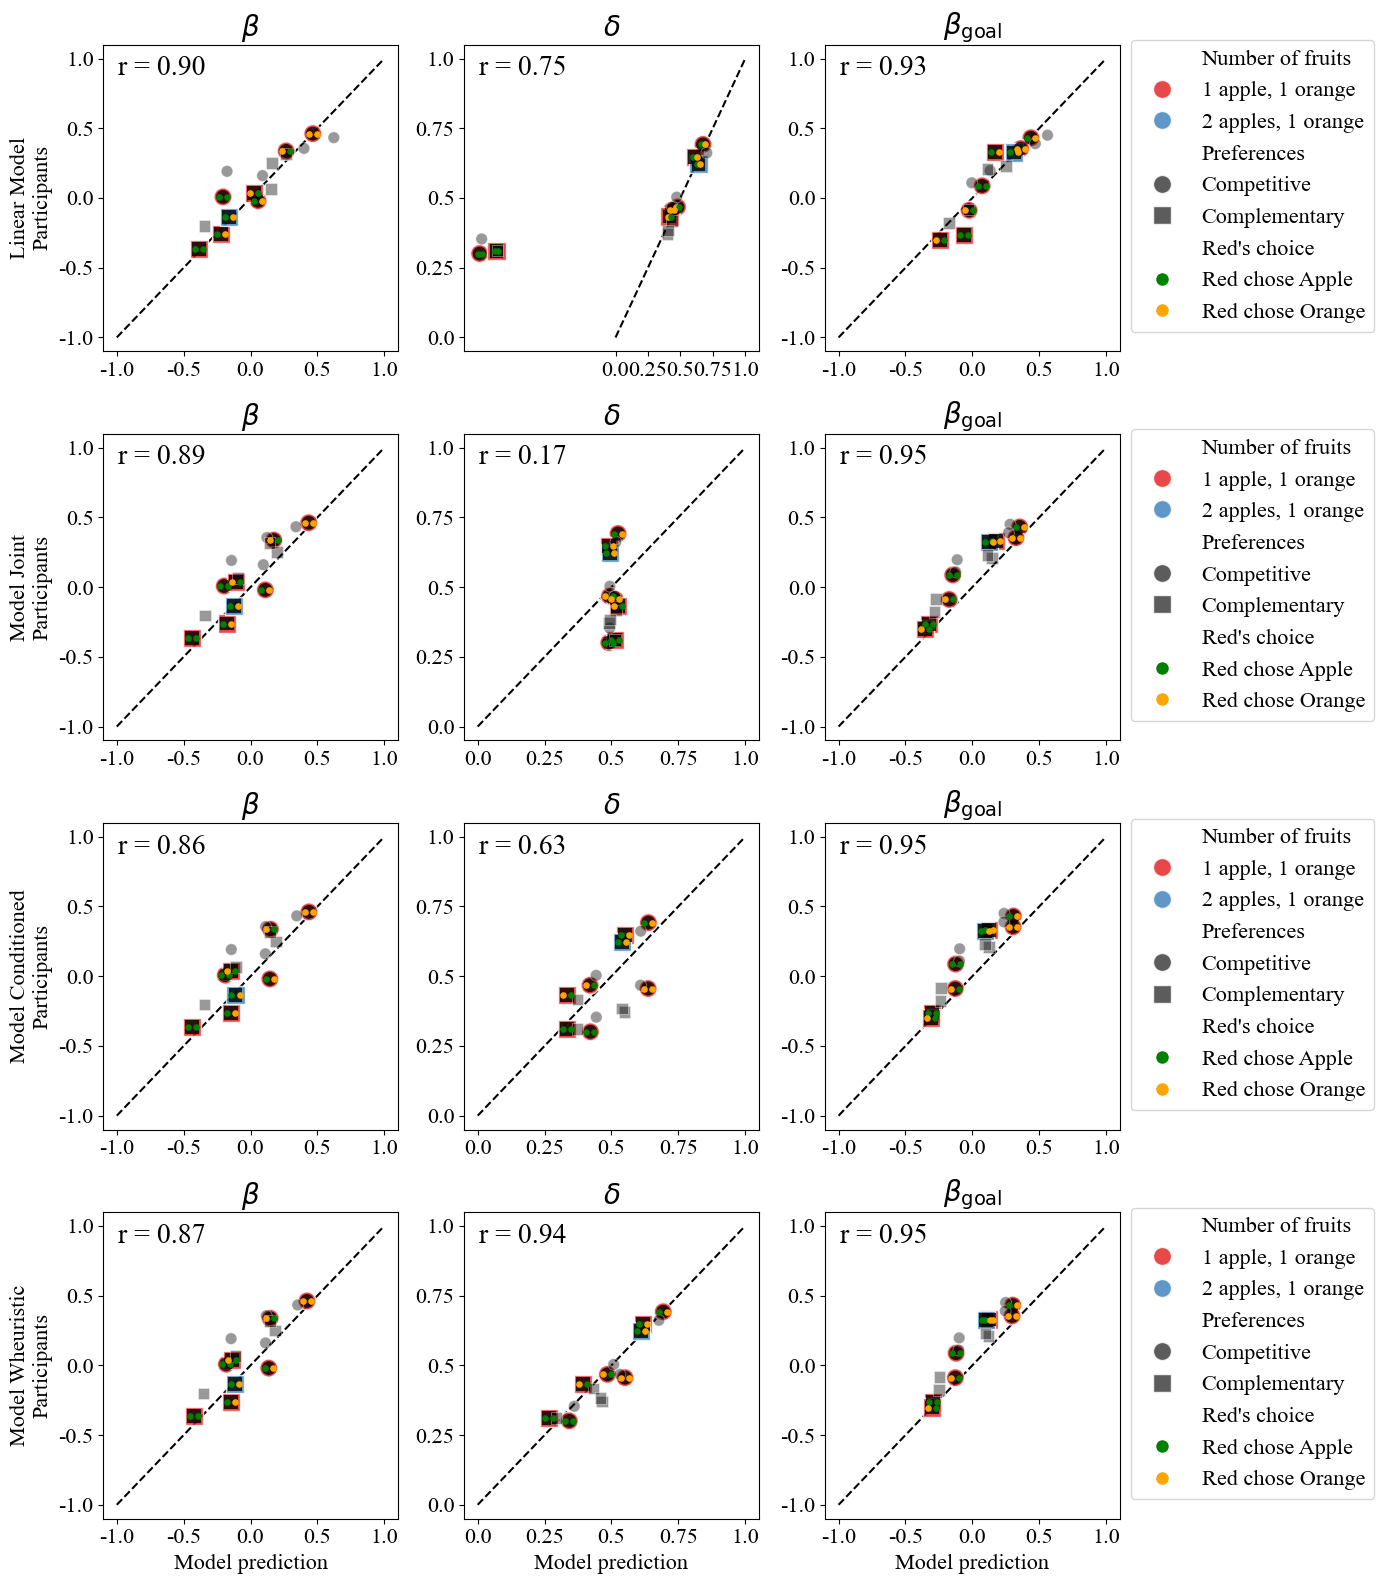

In [23]:
# Plot correlations between model predictions and participant judgements for each model

models = [
    'linear_model',
    'model_joint',
    'model_conditioned',
    'model_wheuristic'
]

param_info = {
    'beta': {
        'name': 'Social Goal $\\beta$',
        'math_name': '$\\beta$',
        'symbol': 'beta',
        'color': 'blue',
        'values': betas
    },
    'delta': {
        'name': 'Presentational Goal $\\delta$',
        'math_name': '$\\delta$',
        'symbol': 'delta',
        'color': 'orange',
        'values': deltas
    },
    'betaP': {
        'name': 'Social Goal for Purple $\\beta_\\text{goal}$',
        'math_name': '$\\beta_\\text{goal}$',
        'symbol': 'betaP',
        'color': 'purple',
        'values': betas
    }
}

fontsizes = {
    'title': 20,
    'labels': 16,
    'ticks': 16,
    'legend': 16,
    'marker': 14   
}

axis_labels = {
    'participants': 'Participants',
    'model': 'Model'
}

def plot_scatter_with_corr(ax, param_label, story_id, model_name, df_story_long, stories_special=[]):
    df_story = df_story_long.pivot(index='story_id', columns='model', values=[param_label]).reset_index()

    
    x_label = axis_labels['model']
    y_label = axis_labels['participants']

    df_story.columns = ['story_id', x_label, y_label]
    # Add story data
    df_story['Preferences'] = df_story['story_id'].apply(lambda x: id_to_story_data(x, out_type='dict')['preferences'])
    df_story['n_apples'] = df_story['story_id'].apply(lambda x: id_to_story_data(x, out_type='dict')['n_apples'])
    df_story['n_oranges'] = df_story['story_id'].apply(lambda x: id_to_story_data(x, out_type='dict')['n_oranges'])
    df_story['choice1'] = df_story['story_id'].apply(lambda x: id_to_story_data(x, out_type='dict')['choice_1']).map({0: 'Apple', 1: 'Orange'})
    df_story['choice2'] = df_story['story_id'].apply(lambda x: id_to_story_data(x, out_type='dict')['choice_2']).map({0: 'Apple', 1: 'Orange'})
    # Rename n_fruits values to be more descriptive
    df_story['Number of fruits'] = df_story['n_apples'] + df_story['n_oranges']
    df_story['Preferences'] = df_story['Preferences'].apply(lambda x: x.capitalize())
    df_story['Number of fruits'] = df_story['Number of fruits'].apply(lambda x: f'1 apple, 1 orange' if x == 2 else (f'2 apples, 1 orange' if x == 3 else '1 apple, 2 oranges'))
    # Set palette for the scatterplot
    sns.set_palette("Set1", n_colors=df_story['Number of fruits'].nunique())

    # Plot unity line behind the scatter points
    ax.plot([param_info[param_label]['values'].min(), param_info[param_label]['values'].max()], 
        [param_info[param_label]['values'].min(), param_info[param_label]['values'].max()], 
        color='black', linestyle='--', zorder=0)
    
    df_story_details = df_story[df_story['story_id'].isin(stories_special)]
    df_story_raw = df_story[~df_story['story_id'].isin(stories_special)]
    
    sns.scatterplot(data=df_story_details, 
                    y=y_label, x=x_label,
                    hue='Number of fruits', 
                    style='Preferences',
                    ax=ax, alpha=0.8,
                    s=170,
                    markers=['o', 's'],
                    palette='Set1')
    
    sns.scatterplot(data=df_story_details, 
                    y=y_label, x=x_label,
                    #hue='same_choice', 
                    style='Preferences', 
                    ax=ax, alpha=0.8,
                    color='black',
                    linewidth=0,
                    s=100,
                    markers=['o', 's'], legend=None)
    
    sns.scatterplot(data=df_story_raw, 
                    y=y_label, x=x_label,
                    #hue='Number of fruits', 
                    style='Preferences',
                    ax=ax, alpha=0.4,
                    s=70,
                    markers=['o', 's'],
                    color='black',
                    legend=None)
    
    # Set xticks labels to be the same as yticks labels and increase font size
    ax.set_xticks(jnp.linspace(param_info[param_label]['values'].min(), param_info[param_label]['values'].max(), 5))
    ax.set_yticks(jnp.linspace(param_info[param_label]['values'].min(), param_info[param_label]['values'].max(), 5))
    ax.set_xticklabels(jnp.linspace(param_info[param_label]['values'].min(), param_info[param_label]['values'].max(), 5), fontsize=fontsizes['ticks'])
    ax.set_yticklabels(jnp.linspace(param_info[param_label]['values'].min(), param_info[param_label]['values'].max(), 5), fontsize=fontsizes['ticks'])
    
    # For each story, plot a green dot for the number of apples picked by A
    offset = 0.015 if param_label == 'delta' else 0.03  # Offset for the x-axis to avoid overlap
    for idx, row in df_story_details.iterrows():
        if row['choice1'] == 'Apple' or row['choice1'] == 'apple':
            color = 'green'
        elif row['choice1'] == 'Orange' or row['choice1'] == 'orange':
            color = 'orange'
        ax.scatter(row[x_label]-offset, row[y_label], color=color, s=fontsizes['marker'])
        if row['choice2'] == 'Apple' or row['choice2'] == 'apple':
            color = 'green'
        elif row['choice2'] == 'Orange' or row['choice2'] == 'orange':
            color = 'orange'
        ax.scatter(row[x_label]+offset, row[y_label], color=color, s=fontsizes['marker'])

    
    
    # Title is correlation and param label
    r = np.corrcoef(df_story[x_label], df_story[y_label])[0, 1]
    ax.text(0.05, 0.9, "r " + f"= {r:.2f}", transform=ax.transAxes, fontsize=fontsizes['title'])

    ax.set_title(f"{param_info[param_label]['math_name']}", fontsize=fontsizes['title'])
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.legend_.remove()
    return ax


fig, axes = plt.subplots(len(models), 3, figsize=(14, 4 * len(models)))


sns.color_palette("Set1")
for i, model_name in enumerate(models):
    df_model = df_model_predictions[df_model_predictions['model'].isin([model_name, 'participants'])]
    
    for j, judgement in enumerate(['beta', 'delta', 'betaP']):
        df_plot = df_model.pivot(index='story_id', columns='model', values=judgement).reset_index()
        df_plot.columns = ['story_id', 'Model prediction', 'Participant judgement']
        ax = axes[i, j]
        ax = plot_scatter_with_corr(
            ax, judgement, story_id, model_name, df_model,
            stories_special=stories_special.flatten()
        )

        if j == 0:
            ax.set_ylabel(f"{model_name.replace('_', ' ').title()}\nParticipants", fontsize=fontsizes['labels'])  
        if i == len(models) - 1:
            ax.set_xlabel(f"Model prediction", fontsize=fontsizes['labels'])  

        if j == 2:
            # Add a green and orange dot explanation for choices in the legend
            green_dot = plt.Line2D([0], [0], marker='o', color='w', label='Red chose Apple', markerfacecolor='green', markersize=10)
            orange_dot = plt.Line2D([0], [0], marker='o', color='w', label='Red chose Orange', markerfacecolor='orange', markersize=10)
            white_dot = plt.Line2D([0], [0], marker='o', color='w', label="Red's choice", markerfacecolor='white', markersize=10)
            # Add to the existing legend, preserving the previous handles
            handles, labels = ax.get_legend_handles_labels()
            handles.extend([white_dot, green_dot, orange_dot])
            labels.extend(["Red's choice", 'Red chose Apple', 'Red chose Orange'])
            ax.legend(handles, labels, loc='upper left', bbox_to_anchor=(1, 1.05), fontsize=fontsizes['legend'])
        else:
            ax.legend().remove()



        

plt.tight_layout()

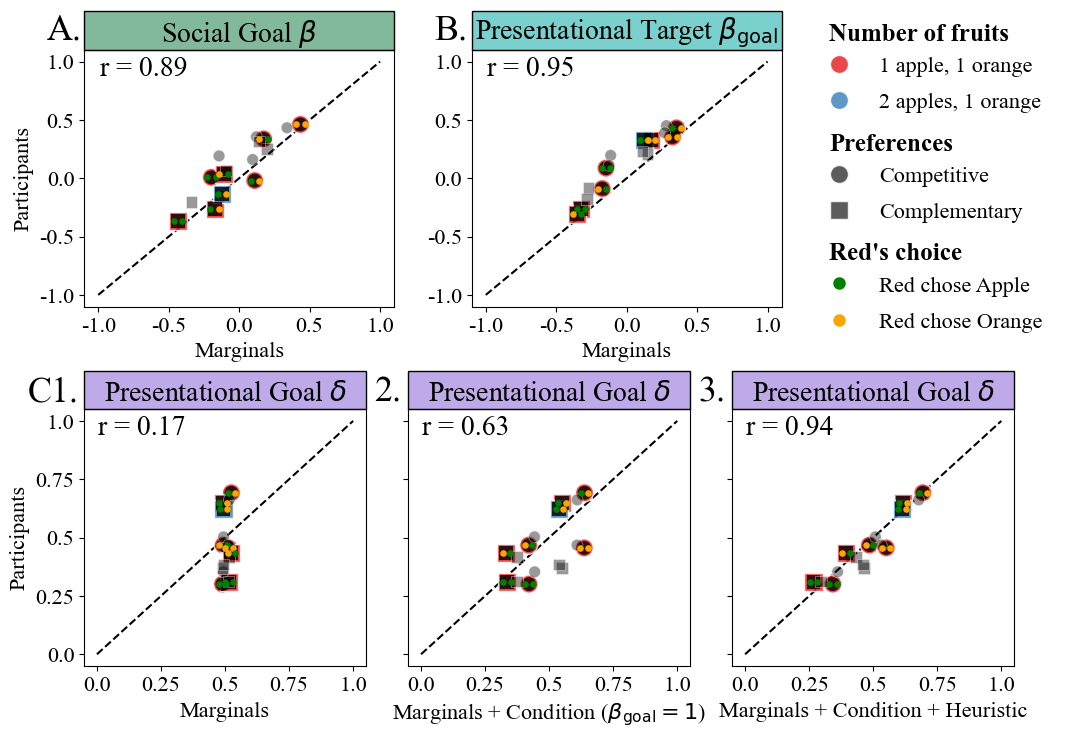

In [24]:
model_name = 'model_joint'
model_names = ['model_joint', 'model_conditioned', 'model_wheuristic']
model_labels = dict(
    model_joint='Marginals',
    model_conditioned='Marginals + Condition ($\\beta_\\text{goal} = 1$)',
    model_wheuristic='Marginals + Condition + Heuristic'
)

param_colors = {
        'social_goal': 'seagreen',
        'presentational_goal': 'mediumpurple',
        'social_goal_purple': 'lightseagreen'
    }


fig = plt.figure(figsize=(12, 8))
gs = plt.GridSpec(2, 1, figure=fig, hspace=0.4)

# Row 1: 3 columns, first is spacer for legend, last 2 are plots
gs_row1 = gs[0].subgridspec(1, 3, wspace=0.3, width_ratios=[1, 1, .5])

# Row 2: 3 axes for delta plots
gs_row2 = gs[1].subgridspec(1, 3, wspace=0.15)

sns.color_palette("Set1")
df_model = df_model_predictions[df_model_predictions['model'].isin([model_name, 'participants'])]

# Plot beta (middle column of row 1)
ax = fig.add_subplot(gs_row1[0])
ax = plot_scatter_with_corr(
    ax, 'beta', story_id, model_name, df_model,
    stories_special=stories_special.flatten()
)
ax.set_ylabel(f"Participants", fontsize=fontsizes['labels'])  
ax.set_xlabel(f"{model_labels[model_name]}", fontsize=fontsizes['labels'])
ax.set_title(f"Social Goal $\\beta$", fontsize=fontsizes['title'])
# Make a box of the width of the xaxis around the title and of the color of param_colors['social_goal']
rect = Rectangle(
    (0, 1.), 1, 0.15, transform=ax.transAxes,
    zorder=0, clip_on=False,
    facecolor=to_rgba(param_colors['social_goal'], 0.6), 
    edgecolor='black', 
    linewidth=1,
)
ax.add_patch(rect)
# Add a text A. to the top left corner
ax.text(-0.12, 1.04, "A.", transform=ax.transAxes, fontsize=fontsizes['title'] + 6)

# Plot betaP (right column of row 1)
ax = fig.add_subplot(gs_row1[1])
ax = plot_scatter_with_corr(
    ax, 'betaP', story_id, model_name, df_model,
    stories_special=stories_special.flatten()
)
ax.set_xlabel(f"{model_labels[model_name]}", fontsize=fontsizes['labels'])
ax.set_title(f"Presentational Target $\\beta_\\text{{goal}}$", fontsize=fontsizes['title'])
# Make a box of the width of the xaxis around the title and of the color of param_colors['social_goal_purple']
rect = Rectangle(
    (0, 1.), 1, 0.15, transform=ax.transAxes,
    zorder=0, clip_on=False,
    facecolor=to_rgba(param_colors['social_goal_purple'], 0.6), 
    edgecolor='black', 
    linewidth=1,
)
ax.add_patch(rect)

# Add a text B. to the top left corner
ax.text(-0.12, 1.04, "B.", transform=ax.transAxes, fontsize=fontsizes['title'] + 6)

# Delta plots in row 2
axes = [fig.add_subplot(gs_row2[i]) for i in range(3)]
axes_labels = ['C1.', '2.', '3.']
for j, model_name in enumerate(model_names):
    df_model = df_model_predictions[df_model_predictions['model'].isin([model_name, 'participants'])]
    ax = axes[j]
    ax = plot_scatter_with_corr(
        ax, 'delta', story_id, model_name, df_model,
        stories_special=stories_special.flatten()
    )
    ax.set_title(f"Presentational Goal $\\delta$", fontsize=fontsizes['title'])
    
    if j == 0:
        ax.set_ylabel(f"Participants", fontsize=fontsizes['labels'])
    else:
        ax.set_ylabel("")
        ax.set_yticklabels([])
    ax.set_xlabel(f"{model_labels[model_name]}", fontsize=fontsizes['labels'])
    # Make a box of the width of the xaxis around the title and of the color of param_colors['presentational_goal']
    rect = Rectangle(
        (0, 1.), 1, 0.15, transform=ax.transAxes,
        zorder=0, clip_on=False,
        facecolor=to_rgba(param_colors['presentational_goal'], 0.6), 
        edgecolor='black', 
        linewidth=1,
    )
    ax.add_patch(rect)
    # Add a text C., 2., 3. to the top left corner
    ax.text(-.2 if j == 0 else -0.12, 1.03, axes_labels[j], transform=ax.transAxes, fontsize=fontsizes['title'] + 6)


ax_legend = fig.add_subplot(gs_row1[2])
ax_legend.axis('off')
# Add legend in the empty first column of row 1
green_dot = plt.Line2D([0], [0], marker='o', color='w', label='Red chose Apple', markerfacecolor='green', markersize=10)
orange_dot = plt.Line2D([0], [0], marker='o', color='w', label='Red chose Orange', markerfacecolor='orange', markersize=10)
white_dot = plt.Line2D([0], [0], marker='o', color='w', label="Red's choice", markerfacecolor='white', markersize=10)

handles, labels = ax.get_legend_handles_labels()
handles.extend([white_dot, green_dot, orange_dot])
labels.extend(["Red's choice", 'Red chose Apple', 'Red chose Orange'])

# Place legend to the left of the row 1 plots
leg = ax_legend.legend(
    handles, labels, 
    loc='upper left', 
    bbox_to_anchor=(-.4, 1.2), 
    fontsize=fontsizes['legend'],
    labelspacing=0.7,
    frameon=False
)

header_indices = [0, 3, 6]
# Style header text (bold)
for i in header_indices:
    text = leg.get_texts()[i]
    text.set_fontweight('bold')
    text.set_fontsize(fontsizes['legend'] + 2)
    text.set_position((-50, -5))  # Shift left; adjust the value as needed


fig.savefig('../figures/exp1_model_correlations.pdf', dpi=300, bbox_inches='tight')

# Compute model comparisons metrics

In [25]:
def compute_model_metrics(data_dists, model_dists_dict, judgement_names, bin_values):
    """
    Compute correlations and KL divergences for each model and judgement.
    Includes a uniform baseline for comparison.
    
    Parameters:
    -----------
    data_dists : np.array
        Observed distributions (n_stories, n_judgements, K)
    model_dists_dict : dict
        Dictionary mapping model names to predicted distributions (n_stories, n_judgements, K)
    judgement_names : list
        List of judgement names
    bin_values : np.array
        Array of shape (n_judgements, K) with bin centers for each judgement
    
    Returns:
    --------
    df_metrics : pd.DataFrame
        Long-form dataframe with columns: model, judgement, r, kl, kl_norm
    """
    
    def kl_divergence(p, q, eps=1e-10):
        """KL(p || q)"""
        p = np.clip(p, eps, 1)
        q = np.clip(q, eps, 1)
        return np.sum(p * np.log(p / q))
    
    def expected_value(dist, values):
        """Compute expected value of a distribution"""
        return np.sum(dist * values)
    
    n_stories, n_judgements, K = data_dists.shape
    
    # Create uniform baseline
    uniform_dist = np.ones((n_stories, n_judgements, K)) / K
    
    # Add uniform to models dict
    model_dists_dict_with_uniform = {'uniform': uniform_dist, **model_dists_dict}
    
    # First pass: compute uniform KL for normalization
    uniform_kls = {}
    for j_idx, judgement in enumerate(judgement_names):
        obs_dists = data_dists[:, j_idx, :]
        uni_dists = uniform_dist[:, j_idx, :]
        kls = np.array([kl_divergence(obs_dists[i], uni_dists[i]) for i in range(n_stories)])
        uniform_kls[judgement] = np.mean(kls)
    
    results = []
    
    for model_name, model_dists in model_dists_dict_with_uniform.items():
        for j_idx, judgement in enumerate(judgement_names):
            obs_dists = data_dists[:, j_idx, :]
            pred_dists = model_dists[:, j_idx, :]
            bins = bin_values[j_idx, :]
            
            # Compute expected values for correlation
            obs_means = np.array([expected_value(d, bins) for d in obs_dists])
            pred_means = np.array([expected_value(d, bins) for d in pred_dists])
            
            # Correlation
            r = np.corrcoef(obs_means, pred_means)[0, 1]
            
            # Mean KL divergence
            kls = np.array([kl_divergence(obs_dists[i], pred_dists[i]) for i in range(n_stories)])
            mean_kl = np.mean(kls)
            
            # Normalized KL (relative to uniform baseline)
            kl_norm = mean_kl / uniform_kls[judgement]
            
            results.append({
                'model': model_name,
                'judgement': judgement,
                'r': r,
                'kl': mean_kl,
                'kl_norm': kl_norm
            })
    
    df_metrics = pd.DataFrame(results)
    
    return df_metrics


judgement_names = ['social_goal', 'presentational_goal', 'social_goal_purple']

# bin_values shape: (3, K)
bin_values = np.array([
    betas,
    deltas,
    betas
])

models_marginals = models_stories_marginals

df_metrics = compute_model_metrics(
    data_dists,
    models_marginals,
    judgement_names,
    bin_values
)

display(df_metrics.groupby(['judgement', 'model'])[['kl_norm']].mean().round(2).unstack().T)
display(df_metrics.groupby(['judgement', 'model'])[['r']].mean().round(2).unstack().T)

judgement                  presentational_goal  social_goal  \
        model                                                 
kl_norm model_conditioned                 0.90         0.82   
        model_joint                       0.99         0.83   
        model_wheuristic                  0.61         0.82   
        uniform                           1.00         1.00   

judgement                  social_goal_purple  
        model                                  
kl_norm model_conditioned                0.82  
        model_joint                      0.82  
        model_wheuristic                 0.82  
        uniform                          1.00

judgement            presentational_goal  social_goal  social_goal_purple
  model                                                                  
r model_conditioned                 0.63         0.86                0.95
  model_joint                       0.17         0.89                0.95
  model_wheuristic                  0.94         0.87                0.95
  uniform                            NaN          NaN                 NaN

(2, 4)


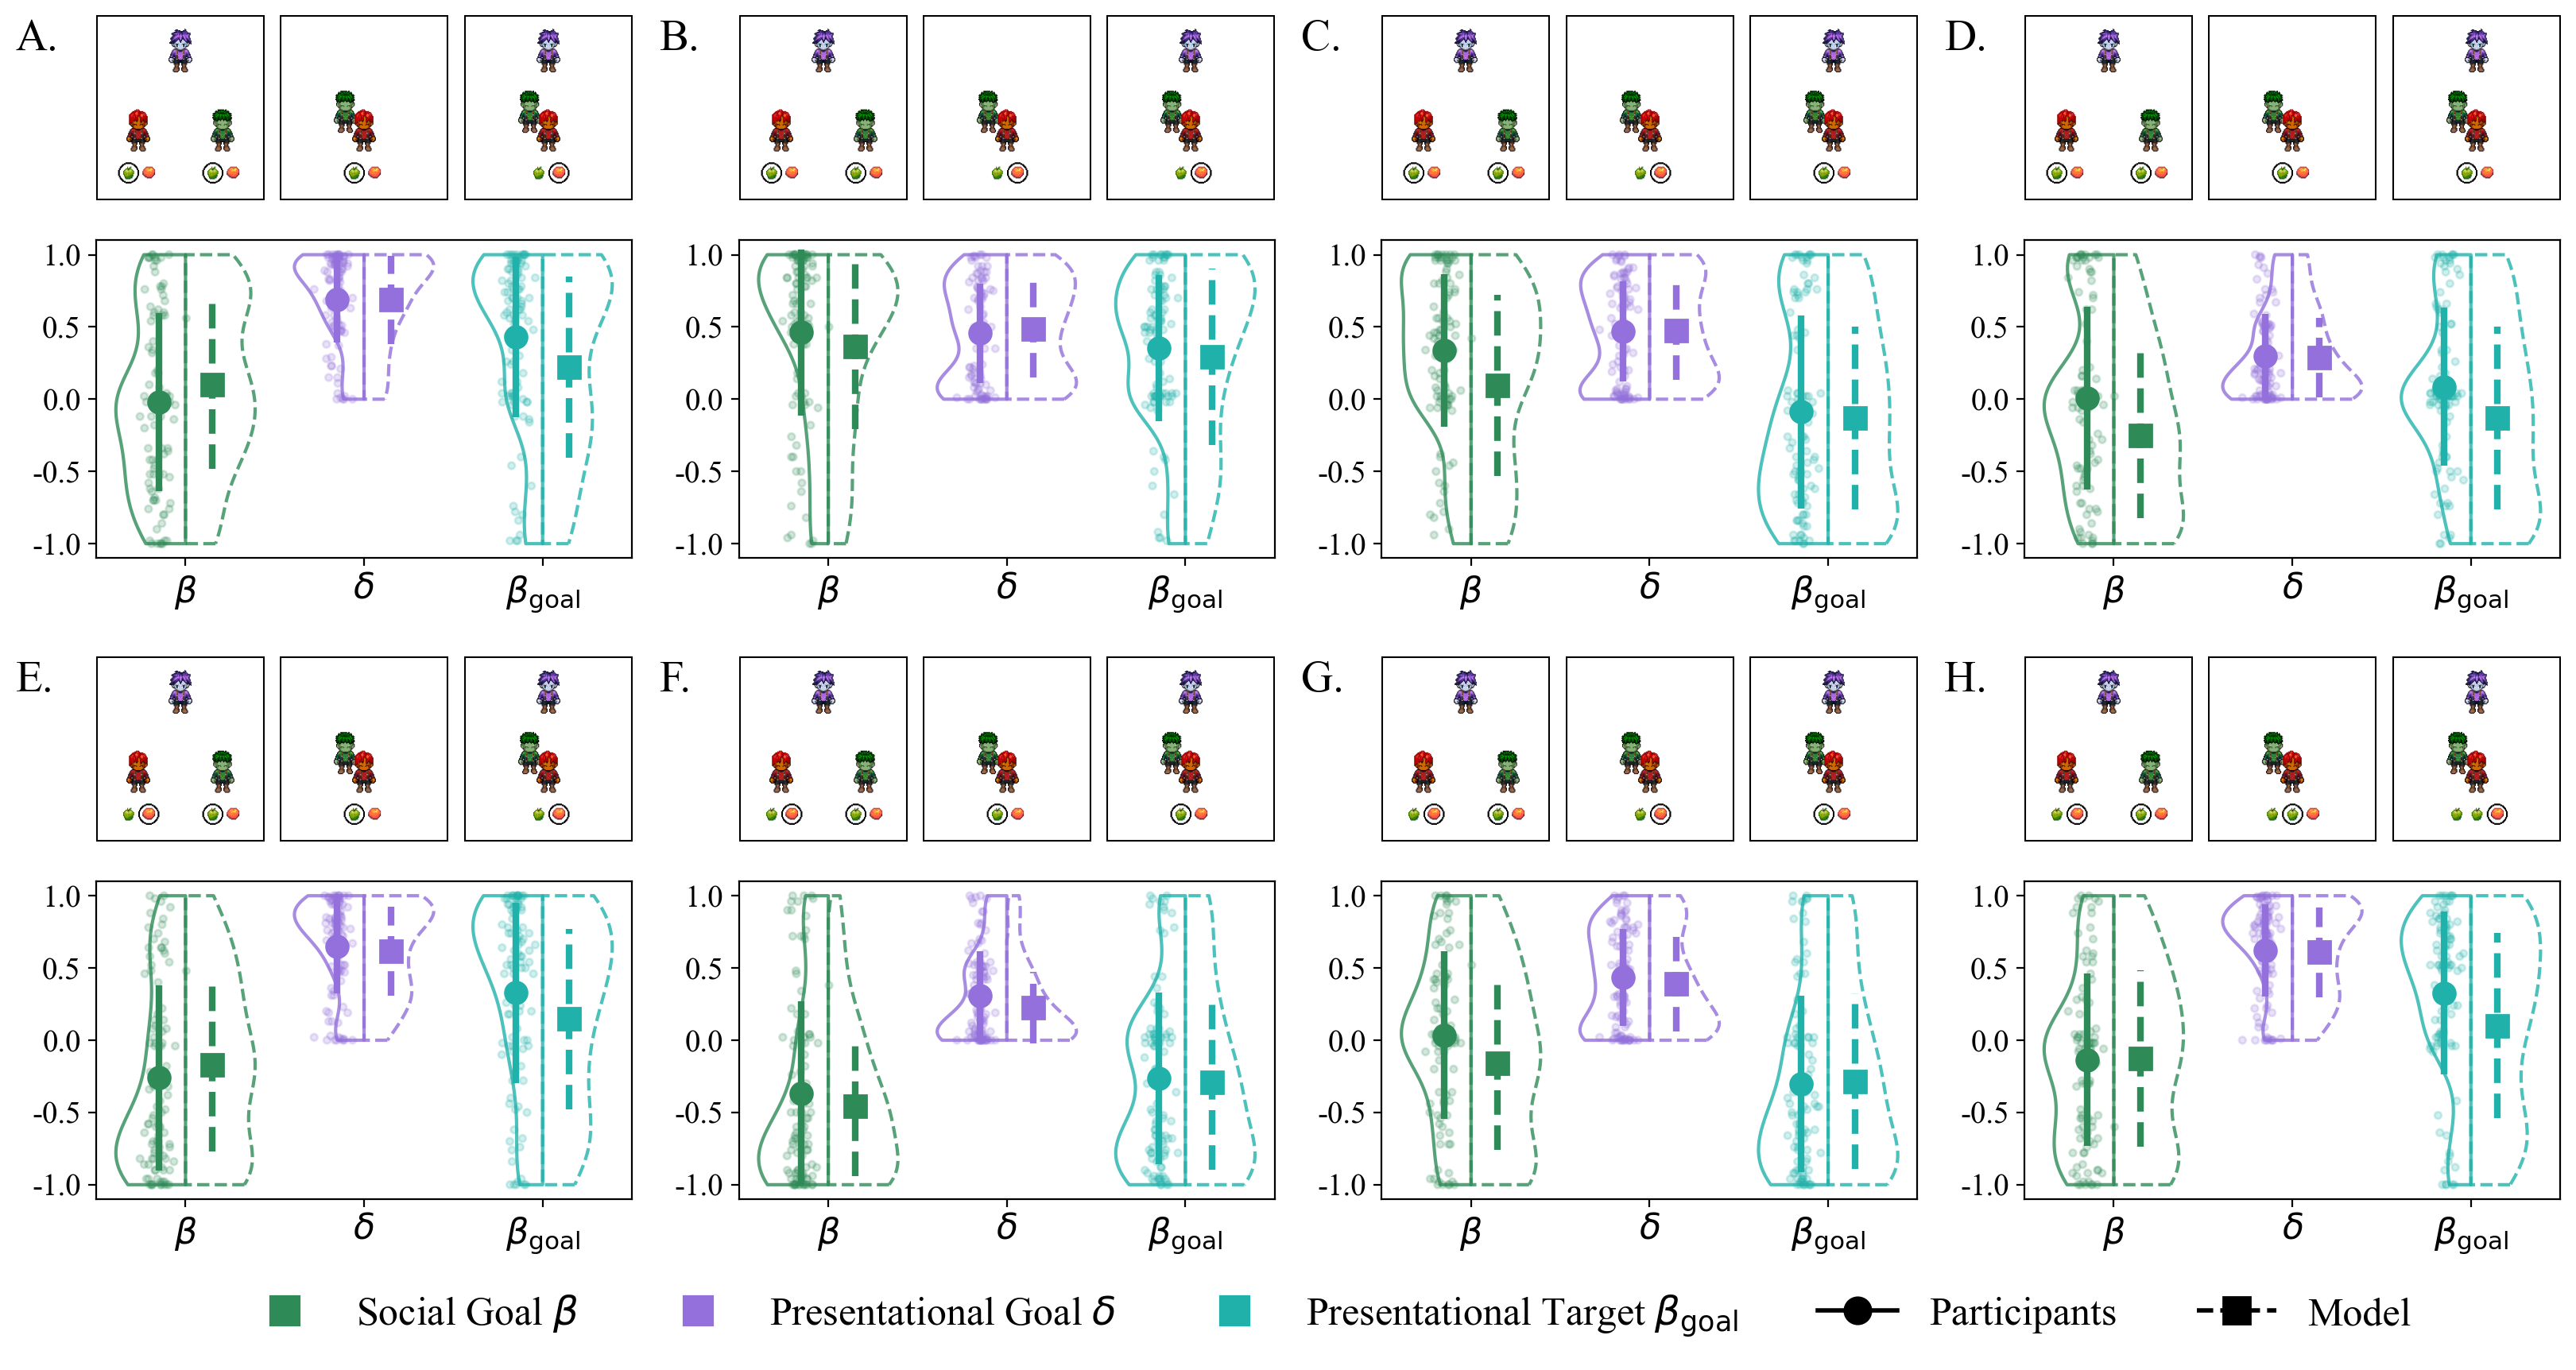

In [26]:


def plot_story_with_distributions(id, i, j, model_to_plot, story, story_marginals, dfl_trials, axes):
    def get_std(dist, values):
        std = np.sqrt(np.sum(dist * (values - np.sum(dist * values))**2))
        return std
    

    pref_R, pref_G, choice1, choice2, n_apples, n_oranges, P_knows_G = parse_code(story, pref_names=False)
    pref_R = Pref(pref_R)
    pref_G = Pref(pref_G)
    choice1 = F(choice1)
    choice2 = F(choice2)
    sim_code, seq_code_1, seq_code_2 = get_im_codes(pref_R, pref_G, choice1, choice2, n_apples, n_oranges, P_knows_G)

    ax_v1 = axes[0]
    divider = make_axes_locatable(ax_v1)
    ax_v2 = divider.append_axes("right", size="100%", pad=0.1)
    ax_v3 = divider.append_axes("right", size="100%", pad=0.1)

    img1 = ax_v1.imshow(plt.imread(f"scene_generation/scenes/{sim_code}.png"))
    ax_v1.axis('off')
    img2 = ax_v2.imshow(plt.imread(f"scene_generation/scenes/{seq_code_1}.png"))
    ax_v2.axis('off')
    img3 = ax_v3.imshow(plt.imread(f"scene_generation/scenes/{seq_code_2}.png"))
    ax_v3.axis('off')

    #ax_v2.set_title('Story', fontsize=12)
    # Plot distributions
    ax = axes[1]
    order = ['social_goal', 'presentational_goal', 'social_goal_purple']

    dfl_story = dfl_trials[(dfl_trials.story_id == story)].copy().sort_values('prolific_id')
    dfl_story['model'] = 'participants'

    PRNGkey = jax.random.PRNGKey(int(np.random.randint(0, 1000000)))
    PRNGkey, subkey = jax.random.split(PRNGkey)
    #samples = sample_from_model(subkey, model_wheuristic_marginals, story, n_samples=200, inv_temp=inv_temp, prior=prior_joint_scaled, weight=weight_heuristic, sd=sd_heuristic)
    samples = sample_from_model(subkey, story_marginals, n_samples=100)
    df_samples_story = pd.DataFrame(samples, columns=['social_goal', 'presentational_goal', 'social_goal_purple'])
    df_samples_story['story_id'] = story
    df_samples_story['model'] = 'model_wheuristic'
    df_samples_story = df_samples_story.melt(id_vars=['story_id', 'model'], var_name='param_label', value_name='param_value')

    dfl_story_violin = pd.concat([dfl_story[['story_id', 'param_label', 'model', 'param_value']], df_samples_story[['story_id', 'param_label', 'model', 'param_value']]], axis=0)

    order = ['social_goal', 'presentational_goal', 'social_goal_purple']

    bounds = {
        'social_goal': (-1, 1),
        'presentational_goal': (0, 1),
        'social_goal_purple': (-1, 1)
    }

    
    # Violin plot - need to plot separately for each param_label to get different colors
    # and for each model to get different line styles
    line_styles = {'participants': '-', f'{model_to_plot}': '--'}

    for i, param in enumerate(order):
        for model in ['participants', model_to_plot]:
            subset = dfl_story_violin[(dfl_story_violin['param_label'] == param) & 
                                       (dfl_story_violin['model'] == model)]
            if len(subset) == 0:
                continue

            data = subset['param_value'].dropna()
            extended_data = np.concatenate([data, bounds[param]])  # Duplicate data for full violin
            
            parts = ax.violinplot(
                extended_data,
                positions=[i + (-0.04 if model == 'participants' else 0.04)],
                widths=.7,
                showmeans=False,
                showextrema=False,
                showmedians=False
            )

            # Style the violin
            for pc in parts['bodies']:

                vertices = pc.get_paths()[0].vertices
                center = i

                if model == 'participants':
                    # Left half: clip all x values to be <= center
                    new_vertices = vertices.copy()
                    new_vertices[:, 0] = np.minimum(vertices[:, 0], center)
                else:
                    # Right half: clip all x values to be >= center
                    new_vertices = vertices.copy()
                    new_vertices[:, 0] = np.maximum(vertices[:, 0], center)

                pc.get_paths()[0].vertices = new_vertices

                pc.set_facecolor('none')
                pc.set_edgecolor(param_colors[param])
                pc.set_linewidth(1.5)
                pc.set_alpha(0.8)
                if model == model_to_plot:
                    pc.set_linestyle('--')

    # Point plot - plot separately to control colors and markers
    markers = {'participants': 'o', f'{model_to_plot}': 's'}

    for i, param in enumerate(order):
        for j, model in enumerate(['participants', model_to_plot]):
            subset = dfl_story_violin[(dfl_story_violin['param_label'] == param) & 
                                       (dfl_story_violin['model'] == model)]
            if len(subset) == 0:
                continue
            
            mean_val = subset['param_value'].mean()
            std_val = subset['param_value'].std()
            ci95 = 1.96 * std_val / np.sqrt(len(subset))

            dodge = -0.15 if model == 'participants' else 0.15
            line, caplines, barlinecols = ax.errorbar(
                i + dodge, mean_val, yerr=std_val,
                fmt=markers[model],
                color=param_colors[param],
                markersize=10,
                capsize=0,
                linewidth=3,
                alpha=1
            )
            # Set linestyle for the error bar lines
            for barline in barlinecols:
                barline.set_linestyle('--' if model == model_to_plot else '-')

    # Scatter plot - color by param_label
    np.random.seed(42)
    x_jitter = (
        dfl_story['param_label']
        .map({k: i for i, k in enumerate(order)})
        + np.random.normal(0, 0.04, size=len(dfl_story))
    )

    # Map colors based on param_label
    scatter_colors = dfl_story['param_label'].map(param_colors)

    ax.scatter(
        x_jitter - 0.15,
        dfl_story['param_value'],
        c=scatter_colors,
        alpha=0.2,
        s=10,
    )

    # Fix x-axis labels
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(order)

    if i < len(stories) - 1:
        ax.legend().remove()
    else:
        ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize='small')


    ax.set_xticks(range(len(dfl_story['param_label'].unique())))
    if i < len(stories) - 1:
        ax.set_xticklabels(['$\\beta$', '$\\delta$', '$\\beta_\\text{goal}$'], fontsize=16)
    else:
        ax.set_xticklabels(['Social Goal\n$\\beta$', '\n\nPresentational Goal\n$\\delta$', 'Social Goal Purple\n$\\beta^P$'], fontsize=10)
    # Make ytick labels larger and bolder
    ax.set_yticks(jnp.linspace(-1, 1, 5))
    ax.set_yticklabels(ax.get_yticks(), fontsize=14)
    
    ax.set_xlabel('')
    if j == 0:
        ax.set_ylabel('', fontsize=16)
    else:
        ax.set_ylabel('')


    # Put ID on the top left corner
    ax_v1.text(-0.15, 1.6, id, transform=ax.transAxes, fontsize=20)


    ax.set_ylim(-1.1, 1.1)
    ax.set_xlim(-0.5, 2.5)

    return (ax_v1, ax_v2, ax_v3)


#stories_block = np.stack([stories_2_fruits.reshape(2, 4), stories_3_fruits.reshape(2, 4)], axis=0).reshape(4, 4)
stories_block = np.stack([stories_2_fruits.reshape(1, len(stories_2_fruits)), stories_3_fruits.reshape(1, len(stories_3_fruits))], axis=0).reshape(2, len(stories_2_fruits))
print(stories_block.shape)


stories_all = df_trials.sort_values('story_id').story_id.unique()

model_to_plot = 'model_wheuristic'

param_colors = {
        'social_goal': 'seagreen',
        'presentational_goal': 'mediumpurple',
        'social_goal_purple': 'lightseagreen'
    }

#fig, axes = plt.subplots(nrows=n_stories, ncols=n_story_variants, figsize=(3.5*n_story_variants, 3.5*n_stories), sharey='row', dpi=200)
fig = plt.figure(figsize=(5*stories_block.shape[1], 5*stories_block.shape[0]), dpi=200)
main_gs = plt.GridSpec(stories_block.shape[0], stories_block.shape[1], wspace=0.2, hspace=0.1)
id = 'A.'
for i in range(stories_block.shape[0]):
    #print(story_short)
    for j in range(stories_block.shape[1]):
        sub_gs = main_gs[i, j].subgridspec(2, 1, wspace=0, hspace=0, height_ratios=[1, 1.2])
        axes = [fig.add_subplot(sub_gs[0]),
                fig.add_subplot(sub_gs[1])]
        story = stories_block[i, j]

        story_marginals = cv_marginals[model_to_plot][stories_all == story].squeeze()
        plot_story_with_distributions(id, i, j, model_to_plot, story, story_marginals, dfl_trials, axes)

        id = chr(ord(id[0]) + 1) + '.'
    #print()

# Keep only the last two handles and labels for the legend
handles, labels = axes[-1].get_legend_handles_labels()
# Make two squares using the colors used in the violin plots
handles_params = [
    plt.Line2D([0], [0], marker='s', color='w', label=param, markerfacecolor=param_colors[param], markersize=15) for param in ['social_goal', 'presentational_goal', 'social_goal_purple']
]
handles_model = [
    plt.Line2D([0], [0], marker='o', color='black', linestyle='-', linewidth=2, label='Participants', markerfacecolor='black', markersize=12),
    plt.Line2D([0], [0], marker='s', color='black', linestyle='--', linewidth=2, label='Model with heuristic', markerfacecolor='black', markersize=12)
]
labels = ['Social Goal $\\beta$', 'Presentational Goal $\\delta$', 'Presentational Target $\\beta_\\text{goal}$']
labels_model = ['Participants', 'Model']
axes[-1].legend(handles_params + handles_model, labels + labels_model, loc='lower center', bbox_to_anchor=(-1.3, -.55), fontsize=18, ncol=6, frameon=False)

# Make suptitle the parameters used
#fig.suptitle(f'Model Predictions vs. Participant Judgements', fontsize=16)
plt.savefig('../figures/exp1_stories_with_distributions.pdf', dpi=300, bbox_inches='tight')